# CART2INSIGHT 

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# 1. LOAD OLIST DATASETS
# ============================================================

datasets = {
    'Customers': pd.read_csv('olist_customers_dataset.csv'),
    'Orders': pd.read_csv('olist_orders_dataset.csv'),
    'Order Items': pd.read_csv('olist_order_items_dataset.csv'),
    'Order Payments': pd.read_csv('olist_order_payments_dataset.csv'),
    'Order Reviews': pd.read_csv('olist_order_reviews_dataset.csv'),
    'Products': pd.read_csv('olist_products_dataset.csv'),
    'Sellers': pd.read_csv('olist_sellers_dataset.csv'),
    'Geolocation': pd.read_csv('olist_geolocation_dataset.csv'),
    'Category Translation': pd.read_csv('product_category_name_translation.csv')
}


In [3]:
# ============================================================
# 2. DATA DICTIONARY + DATA QUALITY REPORT
# ============================================================

data_dictionary = []
data_quality = []

for dataset_name, df in datasets.items():

    # ---------- Data Dictionary ----------
    for column in df.columns:

        # Example value
        non_null_values = df[column].dropna()

        if len(non_null_values) > 0:
            example_value = non_null_values.iloc[0]
        else:
            example_value = None

        data_dictionary.append({
            'Dataset': dataset_name,
            'Column': column,
            'Original Data Type': str(df[column].dtype),
            'Final Data Type': str(df[column].dtype),
            'Missing Count': df[column].isnull().sum(),
            'Missing %': round(df[column].isnull().mean() * 100, 2),
            'Unique Count': df[column].nunique(),
            'Example Value': example_value,
            'Key Type': '',          # Fill manually
            'Description': ''        # Fill manually
        })

    # ---------- Data Quality ----------
    data_quality.append({
        'Dataset': dataset_name,
        'Rows': df.shape[0],
        'Columns': df.shape[1],
        'Total Missing Values': df.isnull().sum().sum(),
        'Missing %': round(
            (df.isnull().sum().sum() /
             (df.shape[0] * df.shape[1])) * 100, 2
        ),
        'Duplicate Rows': df.duplicated().sum()
    })


# Convert lists into DataFrames

data_dictionary_df = pd.DataFrame(data_dictionary)

data_quality_df = pd.DataFrame(data_quality)


# ============================================================
# 3. CLEANING LOG TEMPLATE
# ============================================================

cleaning_log_df = pd.DataFrame(columns=[
    'Dataset',
    'Column',
    'Issue Identified',
    'Before',
    'Action Taken',
    'After',
    'Reason'
])


# ============================================================
# 4. DISPLAY RESULTS
# ============================================================

print("========== DATA DICTIONARY ==========")
display(data_dictionary_df)

print("\n========== DATA QUALITY REPORT ==========")
display(data_quality_df)

print("\n========== CLEANING LOG ==========")
display(cleaning_log_df)


# ============================================================
# 5. EXPORT EVERYTHING TO ONE EXCEL FILE
# ============================================================

with pd.ExcelWriter('olist_data_documentation.xlsx') as writer:

    data_dictionary_df.to_excel(
        writer,
        sheet_name='Data Dictionary',
        index=False
    )

    data_quality_df.to_excel(
        writer,
        sheet_name='Data Quality',
        index=False
    )

    cleaning_log_df.to_excel(
        writer,
        sheet_name='Cleaning Log',
        index=False
    )

print("\nExcel file created: olist_data_documentation.xlsx")

========== DATA DICTIONARY ==========


,Dataset,Column,Original Data Type,Final Data Type,Missing Count,Missing %,Unique Count,Example Value,Key Type,Description
0,Customers,customer_id,object,object,0,0.00,99441,06b8999e2fba1a1fbc88172c00ba8bc7,,
1,Customers,customer_unique_id,object,object,0,0.00,96096,861eff4711a542e4b93843c6dd7febb0,,
2,Customers,customer_zip_code_prefix,int64,int64,0,0.00,14994,14409,,
3,Customers,customer_city,object,object,0,0.00,4119,franca,,
4,Customers,customer_state,object,object,0,0.00,27,SP,,
5,Orders,order_id,object,object,0,0.00,99441,e481f51cbdc54678b7cc49136f2d6af7,,
6,Orders,customer_id,object,object,0,0.00,99441,9ef432eb6251297304e76186b10a928d,,
7,Orders,order_status,object,object,0,0.00,8,delivered,,
8,Orders,order_purchase_timestamp,object,object,0,0.00,98875,2017-10-02 10:56:33,,
9,Orders,order_approved_at,object,object,160,0.16,90733,2017-10-02 11:07:15,,



========== DATA QUALITY REPORT ==========


,Dataset,Rows,Columns,Total Missing Values,Missing %,Duplicate Rows
0,Customers,99441,5,0,0.00,0
1,Orders,99441,8,4908,0.62,0
2,Order Items,112650,7,0,0.00,0
3,Order Payments,103886,5,0,0.00,0
4,Order Reviews,99224,7,145903,21.01,0
5,Products,32951,9,2448,0.83,0
6,Sellers,3095,4,0,0.00,0
7,Geolocation,1000163,5,0,0.00,261831
8,Category Translation,71,2,0,0.00,0



========== CLEANING LOG ==========


,Dataset,Column,Issue Identified,Before,Action Taken,After,Reason



Excel file created: olist_data_documentation.xlsx


In [5]:

# ============================================================
# 1. CREATE COPIES OF ORIGINAL DATASETS
# ============================================================

# We don't want to modify the original raw datasets
cleaned_datasets = {
    name: df.copy()
    for name, df in datasets.items()
}


# ============================================================
# 2. CREATE EMPTY CLEANING LOG
# ============================================================

cleaning_log = []


# ============================================================
# 3. FUNCTION TO ADD AN ENTRY TO CLEANING LOG
# ============================================================

def add_log(dataset, column, issue, before, action, after, reason):

    cleaning_log.append({
        'Dataset': dataset,
        'Column': column,
        'Issue Identified': issue,
        'Before': before,
        'Action Taken': action,
        'After': after,
        'Reason': reason
    })


# ============================================================
# 4. CLEAN EACH DATASET
# ============================================================

for dataset_name, df in cleaned_datasets.items():

    print("=" * 60)
    print(f"Cleaning Dataset: {dataset_name}")
    print("=" * 60)


    # --------------------------------------------------------
    # A. REMOVE DUPLICATE ROWS
    # --------------------------------------------------------

    duplicate_count = df.duplicated().sum()

    if duplicate_count > 0:

        before = f"{duplicate_count} duplicate rows"

        df.drop_duplicates(inplace=True)

        after = f"{df.duplicated().sum()} duplicate rows"

        add_log(
            dataset_name,
            'All Columns',
            'Duplicate rows',
            before,
            'Removed duplicate rows',
            after,
            'Duplicate records can distort analysis and calculations.'
        )


    # --------------------------------------------------------
    # B. REMOVE EXTRA SPACES FROM TEXT COLUMNS
    # --------------------------------------------------------

    for column in df.columns:

        if df[column].dtype == 'object':

            # Count values containing leading/trailing spaces
            before_space_count = (
                df[column]
                .dropna()
                .astype(str)
                .str.strip()
                .ne(df[column].dropna().astype(str))
                .sum()
            )

            if before_space_count > 0:

                df[column] = df[column].apply(
                    lambda x: x.strip() if isinstance(x, str) else x
                )

                add_log(
                    dataset_name,
                    column,
                    'Leading/trailing spaces',
                    f"{before_space_count} values had extra spaces",
                    'Removed leading and trailing spaces',
                    'Spaces removed',
                    'Standardize text values and avoid inconsistent categories.'
                )


    # --------------------------------------------------------
    # C. CONVERT DATE/TIME COLUMNS
    # --------------------------------------------------------

    for column in df.columns:

        column_lower = column.lower()

        # Detect likely date/time columns
        if any(keyword in column_lower for keyword in [
            'date',
            'timestamp',
            'datetime'
        ]):

            # Don't process if already datetime
            if not pd.api.types.is_datetime64_any_dtype(df[column]):

                before_dtype = str(df[column].dtype)

                converted = pd.to_datetime(
                    df[column],
                    errors='coerce'
                )

                invalid_dates = (
                    df[column].notna() &
                    converted.isna()
                ).sum()

                df[column] = converted

                after_dtype = str(df[column].dtype)

                add_log(
                    dataset_name,
                    column,
                    'Date/time stored as incorrect data type',
                    before_dtype,
                    'Converted column to datetime',
                    after_dtype,
                    'Required for time-based analysis, trends and date calculations.'
                )

                if invalid_dates > 0:

                    add_log(
                        dataset_name,
                        column,
                        'Invalid date values',
                        f"{invalid_dates} invalid values",
                        'Converted invalid dates to NaT',
                        f"{df[column].isna().sum()} missing/NaT values",
                        'Invalid dates cannot be used reliably in time-based analysis.'
                    )


    # --------------------------------------------------------
    # D. CONVERT NUMERIC-LOOKING OBJECT COLUMNS
    # --------------------------------------------------------

    for column in df.columns:

        # Skip already numeric/date columns
        if (
            pd.api.types.is_numeric_dtype(df[column]) or
            pd.api.types.is_datetime64_any_dtype(df[column])
        ):
            continue

        # Only attempt conversion if column is object
        if df[column].dtype == 'object':

            original_non_null = df[column].notna().sum()

            if original_non_null == 0:
                continue

            # Remove commas and spaces temporarily
            cleaned_values = (
                df[column]
                .astype(str)
                .str.replace(',', '', regex=False)
                .str.strip()
            )

            numeric_values = pd.to_numeric(
                cleaned_values,
                errors='coerce'
            )

            successfully_converted = numeric_values.notna().sum()

            conversion_ratio = (
                successfully_converted / original_non_null
            )

            # Convert only when most values are numeric
            if conversion_ratio >= 0.90:

                before_dtype = str(df[column].dtype)

                df[column] = numeric_values

                after_dtype = str(df[column].dtype)

                add_log(
                    dataset_name,
                    column,
                    'Numeric values stored as text',
                    before_dtype,
                    'Removed formatting characters and converted to numeric',
                    after_dtype,
                    'Numeric columns are required for calculations, statistics and analysis.'
                )


    # --------------------------------------------------------
    # E. HANDLE MISSING VALUES
    # --------------------------------------------------------

    for column in df.columns:

        missing_before = df[column].isna().sum()

        if missing_before == 0:
            continue


        # ----------------------------------------------------
        # NUMERIC COLUMN → MEDIAN
        # ----------------------------------------------------

        if pd.api.types.is_numeric_dtype(df[column]):

            median_value = df[column].median()

            if pd.notna(median_value):

                df[column] = df[column].fillna(median_value)

                missing_after = df[column].isna().sum()

                add_log(
                    dataset_name,
                    column,
                    'Missing values',
                    f"{missing_before} missing values",
                    f'Filled missing values with median ({median_value})',
                    f"{missing_after} missing values",
                    'Median is less affected by extreme values and preserves the dataset size.'
                )


        # ----------------------------------------------------
        # TEXT/CATEGORICAL COLUMN → MODE
        # ----------------------------------------------------

        elif df[column].dtype == 'object':

            mode_values = df[column].mode()

            if len(mode_values) > 0:

                mode_value = mode_values.iloc[0]

                df[column] = df[column].fillna(mode_value)

                missing_after = df[column].isna().sum()

                add_log(
                    dataset_name,
                    column,
                    'Missing values',
                    f"{missing_before} missing values",
                    f"Filled missing values with mode ('{mode_value}')",
                    f"{missing_after} missing values",
                    'Mode is appropriate for categorical values when retaining records is important.'
                )


        # ----------------------------------------------------
        # DATETIME COLUMN → DO NOT IMPUTE
        # ----------------------------------------------------

        elif pd.api.types.is_datetime64_any_dtype(df[column]):

            add_log(
                dataset_name,
                column,
                'Missing date/time values',
                f"{missing_before} missing values",
                'Missing date/time values retained as NaT',
                f"{missing_before} missing values",
                'Artificially creating dates could introduce incorrect time information.'
            )


    # --------------------------------------------------------
    # F. REPORT REMAINING MISSING VALUES
    # --------------------------------------------------------

    remaining_missing = df.isna().sum().sum()

    print(f"Remaining missing values: {remaining_missing}")
    print(f"Rows: {df.shape[0]}")
    print(f"Columns: {df.shape[1]}")
    print()


# ============================================================
# 5. CREATE CLEANING LOG DATAFRAME
# ============================================================

cleaning_log_df = pd.DataFrame(cleaning_log)


# ============================================================
# 6. CREATE FINAL DATA QUALITY REPORT
# ============================================================

data_quality = []

for dataset_name, df in cleaned_datasets.items():

    total_cells = df.shape[0] * df.shape[1]

    total_missing = df.isna().sum().sum()

    missing_percentage = (
        total_missing / total_cells * 100
        if total_cells > 0
        else 0
    )

    data_quality.append({

        'Dataset': dataset_name,

        'Rows': df.shape[0],

        'Columns': df.shape[1],

        'Total Missing Values': total_missing,

        'Missing %': round(
            missing_percentage,
            2
        ),

        'Duplicate Rows': df.duplicated().sum()

    })


data_quality_df = pd.DataFrame(data_quality)


# ============================================================
# 7. CREATE FINAL DATA DICTIONARY
# ============================================================

data_dictionary = []

for dataset_name, df in cleaned_datasets.items():

    for column in df.columns:

        non_null_values = df[column].dropna()

        if len(non_null_values) > 0:

            example_value = non_null_values.iloc[0]

        else:

            example_value = None


        data_dictionary.append({

            'Dataset': dataset_name,

            'Column': column,

            'Final Data Type': str(
                df[column].dtype
            ),

            'Missing Count': df[column].isna().sum(),

            'Missing %': round(
                df[column].isna().mean() * 100,
                2
            ),

            'Unique Count': df[column].nunique(),

            'Example Value': example_value,

            'Key Type': '',

            'Description': ''

        })


data_dictionary_df = pd.DataFrame(
    data_dictionary
)


# ============================================================
# 8. DISPLAY RESULTS
# ============================================================

print("\n" + "=" * 70)
print("CLEANING LOG")
print("=" * 70)

display(cleaning_log_df)


print("\n" + "=" * 70)
print("FINAL DATA QUALITY REPORT")
print("=" * 70)

display(data_quality_df)


print("\n" + "=" * 70)
print("FINAL DATA DICTIONARY")
print("=" * 70)

display(data_dictionary_df)


# ============================================================
# 9. EXPORT DOCUMENTATION TO EXCEL
# ============================================================

with pd.ExcelWriter(
    'olist_data_documentation.xlsx',
    engine='openpyxl'
) as writer:

    data_dictionary_df.to_excel(
        writer,
        sheet_name='Data Dictionary',
        index=False
    )

    data_quality_df.to_excel(
        writer,
        sheet_name='Data Quality',
        index=False
    )

    cleaning_log_df.to_excel(
        writer,
        sheet_name='Cleaning Log',
        index=False
    )


Cleaning Dataset: Customers
Remaining missing values: 0
Rows: 99441
Columns: 5

Cleaning Dataset: Orders
Remaining missing values: 4748
Rows: 99441
Columns: 8

Cleaning Dataset: Order Items
Remaining missing values: 0
Rows: 112650
Columns: 7

Cleaning Dataset: Order Payments
Remaining missing values: 0
Rows: 103886
Columns: 5

Cleaning Dataset: Order Reviews
Remaining missing values: 0
Rows: 99224
Columns: 7

Cleaning Dataset: Products
Remaining missing values: 0
Rows: 32951
Columns: 9

Cleaning Dataset: Sellers
Remaining missing values: 0
Rows: 3095
Columns: 4

Cleaning Dataset: Geolocation
Remaining missing values: 0
Rows: 738332
Columns: 5

Cleaning Dataset: Category Translation
Remaining missing values: 0
Rows: 71
Columns: 2


CLEANING LOG


,Dataset,Column,Issue Identified,Before,Action Taken,After,Reason
0,Orders,order_purchase_timestamp,Date/time stored as incorrect data type,object,Converted column to datetime,datetime64[ns],"Required for time-based analysis, trends and d..."
1,Orders,order_delivered_carrier_date,Date/time stored as incorrect data type,object,Converted column to datetime,datetime64[ns],"Required for time-based analysis, trends and d..."
2,Orders,order_delivered_customer_date,Date/time stored as incorrect data type,object,Converted column to datetime,datetime64[ns],"Required for time-based analysis, trends and d..."
3,Orders,order_estimated_delivery_date,Date/time stored as incorrect data type,object,Converted column to datetime,datetime64[ns],"Required for time-based analysis, trends and d..."
4,Orders,order_approved_at,Missing values,160 missing values,Filled missing values with mode ('2018-02-27 0...,0 missing values,Mode is appropriate for categorical values whe...
5,Orders,order_delivered_carrier_date,Missing date/time values,1783 missing values,Missing date/time values retained as NaT,1783 missing values,Artificially creating dates could introduce in...
6,Orders,order_delivered_customer_date,Missing date/time values,2965 missing values,Missing date/time values retained as NaT,2965 missing values,Artificially creating dates could introduce in...
7,Order Items,shipping_limit_date,Date/time stored as incorrect data type,object,Converted column to datetime,datetime64[ns],"Required for time-based analysis, trends and d..."
8,Order Reviews,review_comment_title,Leading/trailing spaces,1998 values had extra spaces,Removed leading and trailing spaces,Spaces removed,Standardize text values and avoid inconsistent...
9,Order Reviews,review_comment_message,Leading/trailing spaces,9451 values had extra spaces,Removed leading and trailing spaces,Spaces removed,Standardize text values and avoid inconsistent...



FINAL DATA QUALITY REPORT


,Dataset,Rows,Columns,Total Missing Values,Missing %,Duplicate Rows
0,Customers,99441,5,0,0.0,0
1,Orders,99441,8,4748,0.6,0
2,Order Items,112650,7,0,0.0,0
3,Order Payments,103886,5,0,0.0,0
4,Order Reviews,99224,7,0,0.0,0
5,Products,32951,9,0,0.0,0
6,Sellers,3095,4,0,0.0,0
7,Geolocation,738332,5,0,0.0,0
8,Category Translation,71,2,0,0.0,0



FINAL DATA DICTIONARY


,Dataset,Column,Final Data Type,Missing Count,Missing %,Unique Count,Example Value,Key Type,Description
0,Customers,customer_id,object,0,0.00,99441,06b8999e2fba1a1fbc88172c00ba8bc7,,
1,Customers,customer_unique_id,object,0,0.00,96096,861eff4711a542e4b93843c6dd7febb0,,
2,Customers,customer_zip_code_prefix,int64,0,0.00,14994,14409,,
3,Customers,customer_city,object,0,0.00,4119,franca,,
4,Customers,customer_state,object,0,0.00,27,SP,,
5,Orders,order_id,object,0,0.00,99441,e481f51cbdc54678b7cc49136f2d6af7,,
6,Orders,customer_id,object,0,0.00,99441,9ef432eb6251297304e76186b10a928d,,
7,Orders,order_status,object,0,0.00,8,delivered,,
8,Orders,order_purchase_timestamp,datetime64[ns],0,0.00,98875,2017-10-02 10:56:33,,
9,Orders,order_approved_at,object,0,0.00,90733,2017-10-02 11:07:15,,


In [6]:
# ============================================================
# 10. EXPORT CLEANED DATASETS AS CSV
# ============================================================

for dataset_name, df in cleaned_datasets.items():

    file_name = (
        dataset_name
        .lower()
        .replace(' ', '_')
        .replace('-', '_')
    )

    df.to_csv(
        f'cleaned_{file_name}.csv',
        index=False
    )

    print(f"Saved: cleaned_{file_name}.csv")


print("\nAll cleaned datasets exported successfully!")

Saved: cleaned_customers.csv
Saved: cleaned_orders.csv
Saved: cleaned_order_items.csv
Saved: cleaned_order_payments.csv
Saved: cleaned_order_reviews.csv
Saved: cleaned_products.csv
Saved: cleaned_sellers.csv
Saved: cleaned_geolocation.csv
Saved: cleaned_category_translation.csv

All cleaned datasets exported successfully!


In [21]:
# ============================================================
# 10. FEATURE ENGINEERING
# ============================================================

# Feature engineering is performed on CLEANED datasets.
# The original raw datasets remain unchanged.

fe_datasets = {
    name: df.copy()
    for name, df in cleaned_datasets.items()
}


# ============================================================
# A. ORDER FEATURES
# ============================================================

orders = fe_datasets['Orders']


# ------------------------------------------------------------
# Delivery time
# ------------------------------------------------------------

orders['delivery_days'] = (
    orders['order_delivered_customer_date']
    - orders['order_purchase_timestamp']
).dt.total_seconds() / (24 * 60 * 60)


# ------------------------------------------------------------
# Estimated delivery time
# ------------------------------------------------------------

orders['estimated_delivery_days'] = (
    orders['order_estimated_delivery_date']
    - orders['order_purchase_timestamp']
).dt.total_seconds() / (24 * 60 * 60)


# ------------------------------------------------------------
# Delivery delay
# ------------------------------------------------------------

orders['delivery_delay_days'] = (
    orders['order_delivered_customer_date']
    - orders['order_estimated_delivery_date']
).dt.total_seconds() / (24 * 60 * 60)


# ------------------------------------------------------------
# Delivery performance
# ------------------------------------------------------------

orders['delivery_performance'] = np.select(
    [
        orders['delivery_delay_days'].isna(),
        orders['delivery_delay_days'] > 0
    ],
    [
        'Not Delivered',
        'Late'
    ],
    default='On Time'
)


# ============================================================
# B. TIME FEATURES
# ============================================================

orders['order_year'] = (
    orders['order_purchase_timestamp'].dt.year
)

orders['order_month'] = (
    orders['order_purchase_timestamp'].dt.month
)

orders['order_month_name'] = (
    orders['order_purchase_timestamp'].dt.month_name()
)

orders['order_quarter'] = (
    orders['order_purchase_timestamp'].dt.quarter
)

orders['order_day_name'] = (
    orders['order_purchase_timestamp'].dt.day_name()
)


# ============================================================
# C. SAVE FEATURE-ENGINEERED ORDERS
# ============================================================

fe_datasets['Orders'] = orders


# ============================================================
# D. CHECK RESULTS
# ============================================================

print("=" * 70)
print("FEATURE ENGINEERING - ORDERS")
print("=" * 70)

display(
    orders[
        [
            'order_id',
            'order_purchase_timestamp',
            'order_delivered_customer_date',
            'order_estimated_delivery_date',
            'delivery_days',
            'estimated_delivery_days',
            'delivery_delay_days',
            'delivery_performance',
            'order_year',
            'order_month',
            'order_month_name',
            'order_quarter',
            'order_day_name'
        ]
    ].head()
)

FEATURE ENGINEERING - ORDERS


,order_id,order_purchase_timestamp,order_delivered_customer_date,order_estimated_delivery_date,delivery_days,estimated_delivery_days,delivery_delay_days,delivery_performance,order_year,order_month,order_month_name,order_quarter,order_day_name
0,e481f51cbdc54678b7cc49136f2d6af7,2017-10-02 10:56:33,2017-10-10 21:25:13,2017-10-18,8.436574,15.544063,-7.107488,On Time,2017,10,October,4,Monday
1,53cdb2fc8bc7dce0b6741e2150273451,2018-07-24 20:41:37,2018-08-07 15:27:45,2018-08-13,13.782037,19.137766,-5.355729,On Time,2018,7,July,3,Tuesday
2,47770eb9100c2d0c44946d9cf07ec65d,2018-08-08 08:38:49,2018-08-17 18:06:29,2018-09-04,9.394213,26.639711,-17.245498,On Time,2018,8,August,3,Wednesday
3,949d5b44dbf5de918fe9c16f97b45f8a,2017-11-18 19:28:06,2017-12-02 00:28:42,2017-12-15,13.208750,26.188819,-12.980069,On Time,2017,11,November,4,Saturday
4,ad21c59c0840e6cb83a9ceb5573f8159,2018-02-13 21:18:39,2018-02-16 18:17:02,2018-02-26,2.873877,12.112049,-9.238171,On Time,2018,2,February,1,Tuesday


In [43]:
# ============================================================
# 11. FEATURE ENGINEERING - ORDER ITEMS
# ============================================================

order_items = fe_datasets['Order Items'].copy()

# Total value = product price + freight
order_items['total_item_value'] = (
    order_items['price'] +
    order_items['freight_value']
)

# Freight as percentage of product price
order_items['freight_percentage'] = np.where(
    order_items['price'] > 0,
    (order_items['freight_value'] / order_items['price']) * 100,
    np.nan
)

fe_datasets['Order Items'] = order_items

display(
    order_items[
        [
            'order_id',
            'product_id',
            'price',
            'freight_value',
            'total_item_value',
            'freight_percentage'
        ]
    ].head()
)

,order_id,product_id,price,freight_value,total_item_value,freight_percentage
0,00010242fe8c5a6d1ba2dd792cb16214,4244733e06e7ecb4970a6e2683c13e61,58.90,13.29,72.19,22.563667
1,00018f77f2f0320c557190d7a144bdd3,e5f2d52b802189ee658865ca93d83a8f,239.90,19.93,259.83,8.307628
2,000229ec398224ef6ca0657da4fc703e,c777355d18b72b67abbeef9df44fd0fd,199.00,17.87,216.87,8.979899
3,00024acbcdf0a6daa1e931b038114c75,7634da152a4610f1595efa32f14722fc,12.99,12.79,25.78,98.460354
4,00042b26cf59d7ce69dfabb4e55b4fd9,ac6c3623068f30de03045865e4e10089,199.90,18.14,218.04,9.074537


In [14]:
# ============================================================
# 12. FEATURE ENGINEERING - PRODUCTS
# ============================================================

products = fe_datasets['Products'].copy()

# Convert weight from grams to kilograms
products['product_weight_kg'] = (
    products['product_weight_g'] / 1000
)

# Calculate product volume
products['product_volume_cm3'] = (
    products['product_length_cm']
    * products['product_height_cm']
    * products['product_width_cm']
)

fe_datasets['Products'] = products

display(
    products[
        [
            'product_id',
            'product_weight_g',
            'product_weight_kg',
            'product_length_cm',
            'product_height_cm',
            'product_width_cm',
            'product_volume_cm3'
        ]
    ].head()
)

,product_id,product_weight_g,product_weight_kg,product_length_cm,product_height_cm,product_width_cm,product_volume_cm3
0,1e9e8ef04dbcff4541ed26657ea517e5,225.0,0.225,16.0,10.0,14.0,2240.0
1,3aa071139cb16b67ca9e5dea641aaa2f,1000.0,1.000,30.0,18.0,20.0,10800.0
2,96bd76ec8810374ed1b65e291975717f,154.0,0.154,18.0,9.0,15.0,2430.0
3,cef67bcfe19066a932b7673e239eb23d,371.0,0.371,26.0,4.0,26.0,2704.0
4,9dc1a7de274444849c219cff195d0b71,625.0,0.625,20.0,17.0,13.0,4420.0


In [15]:
# ============================================================
# 13. FEATURE ENGINEERING - ORDER PAYMENTS
# ============================================================

order_payments = fe_datasets['Order Payments'].copy()

# Average payment amount per installment
order_payments['payment_per_installment'] = np.where(
    order_payments['payment_installments'] > 0,
    (
        order_payments['payment_value']
        / order_payments['payment_installments']
    ),
    np.nan
)

fe_datasets['Order Payments'] = order_payments

display(
    order_payments[
        [
            'order_id',
            'payment_type',
            'payment_value',
            'payment_installments',
            'payment_per_installment'
        ]
    ].head()
)

,order_id,payment_type,payment_value,payment_installments,payment_per_installment
0,b81ef226f3fe1789b1e8b2acac839d17,credit_card,99.33,8,12.41625
1,a9810da82917af2d9aefd1278f1dcfa0,credit_card,24.39,1,24.39000
2,25e8ea4e93396b6fa0d3dd708e76c1bd,credit_card,65.71,1,65.71000
3,ba78997921bbcdc1373bb41e913ab953,credit_card,107.78,8,13.47250
4,42fdf880ba16b47b59251dd489d4441a,credit_card,128.45,2,64.22500


In [16]:
# ============================================================
# 14. FEATURE ENGINEERING - ORDER REVIEWS
# ============================================================

order_reviews = fe_datasets['Order Reviews'].copy()

order_reviews['review_category'] = np.select(
    [
        order_reviews['review_score'] <= 2,
        order_reviews['review_score'] == 3,
        order_reviews['review_score'] >= 4
    ],
    [
        'Negative',
        'Neutral',
        'Positive'
    ],
    default='Unknown'
)

fe_datasets['Order Reviews'] = order_reviews

display(
    order_reviews[
        [
            'review_id',
            'order_id',
            'review_score',
            'review_category'
        ]
    ].head()
)

,review_id,order_id,review_score,review_category
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,Positive
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,Positive
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,Positive
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,Positive
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,Positive


In [17]:
# ============================================================
# 15. FEATURE ENGINEERING - CUSTOMERS
# ============================================================

customers = fe_datasets['Customers'].copy()

customers['customer_location'] = (
    customers['customer_city'].astype(str)
    + ', '
    + customers['customer_state'].astype(str)
)

fe_datasets['Customers'] = customers

display(
    customers[
        [
            'customer_id',
            'customer_city',
            'customer_state',
            'customer_location'
        ]
    ].head()
)

,customer_id,customer_city,customer_state,customer_location
0,06b8999e2fba1a1fbc88172c00ba8bc7,franca,SP,"franca, SP"
1,18955e83d337fd6b2def6b18a428ac77,sao bernardo do campo,SP,"sao bernardo do campo, SP"
2,4e7b3e00288586ebd08712fdd0374a03,sao paulo,SP,"sao paulo, SP"
3,b2b6027bc5c5109e529d4dc6358b12c3,mogi das cruzes,SP,"mogi das cruzes, SP"
4,4f2d8ab171c80ec8364f7c12e35b23ad,campinas,SP,"campinas, SP"


In [18]:
# ============================================================
# 16. FEATURE ENGINEERING - SELLERS
# ============================================================

sellers = fe_datasets['Sellers'].copy()

sellers['seller_location'] = (
    sellers['seller_city'].astype(str)
    + ', '
    + sellers['seller_state'].astype(str)
)

fe_datasets['Sellers'] = sellers

display(
    sellers[
        [
            'seller_id',
            'seller_city',
            'seller_state',
            'seller_location'
        ]
    ].head()
)

,seller_id,seller_city,seller_state,seller_location
0,3442f8959a84dea7ee197c632cb2df15,campinas,SP,"campinas, SP"
1,d1b65fc7debc3361ea86b5f14c68d2e2,mogi guacu,SP,"mogi guacu, SP"
2,ce3ad9de960102d0677a81f5d0bb7b2d,rio de janeiro,RJ,"rio de janeiro, RJ"
3,c0f3eea2e14555b6faeea3dd58c1b1c3,sao paulo,SP,"sao paulo, SP"
4,51a04a8a6bdcb23deccc82b0b80742cf,braganca paulista,SP,"braganca paulista, SP"


In [19]:
# ============================================================
# 17. FEATURE ENGINEERING - FINAL CHECK
# ============================================================

for name, df in fe_datasets.items():

    print("=" * 60)
    print(f"Dataset: {name}")
    print(f"Rows   : {df.shape[0]:,}")
    print(f"Columns: {df.shape[1]:,}")
    print("=" * 60)

Dataset: Customers
Rows   : 99,441
Columns: 6
Dataset: Orders
Rows   : 99,441
Columns: 17
Dataset: Order Items
Rows   : 112,650
Columns: 9
Dataset: Order Payments
Rows   : 103,886
Columns: 6
Dataset: Order Reviews
Rows   : 99,224
Columns: 8
Dataset: Products
Rows   : 32,951
Columns: 11
Dataset: Sellers
Rows   : 3,095
Columns: 5
Dataset: Geolocation
Rows   : 738,332
Columns: 5
Dataset: Category Translation
Rows   : 71
Columns: 2


In [20]:
print("Orders:")
print(fe_datasets['Orders'].columns.tolist())

print("\nOrder Items:")
print(fe_datasets['Order Items'].columns.tolist())

print("\nProducts:")
print(fe_datasets['Products'].columns.tolist())

print("\nOrder Payments:")
print(fe_datasets['Order Payments'].columns.tolist())

print("\nOrder Reviews:")
print(fe_datasets['Order Reviews'].columns.tolist())

Orders:
['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'delivery_days', 'estimated_delivery_days', 'delivery_delay_days', 'delivery_performance', 'order_year', 'order_month', 'order_month_name', 'order_quarter', 'order_day_name']

Order Items:
['order_id', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value', 'total_item_value', 'freight_percentage']

Products:
['product_id', 'product_category_name', 'product_name_lenght', 'product_description_lenght', 'product_photos_qty', 'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm', 'product_weight_kg', 'product_volume_cm3']

Order Payments:
['order_id', 'payment_sequential', 'payment_type', 'payment_installments', 'payment_value', 'payment_per_installment']

Order Reviews:
['review_id', 'order_id', 'review_score', 'review_comment_tit

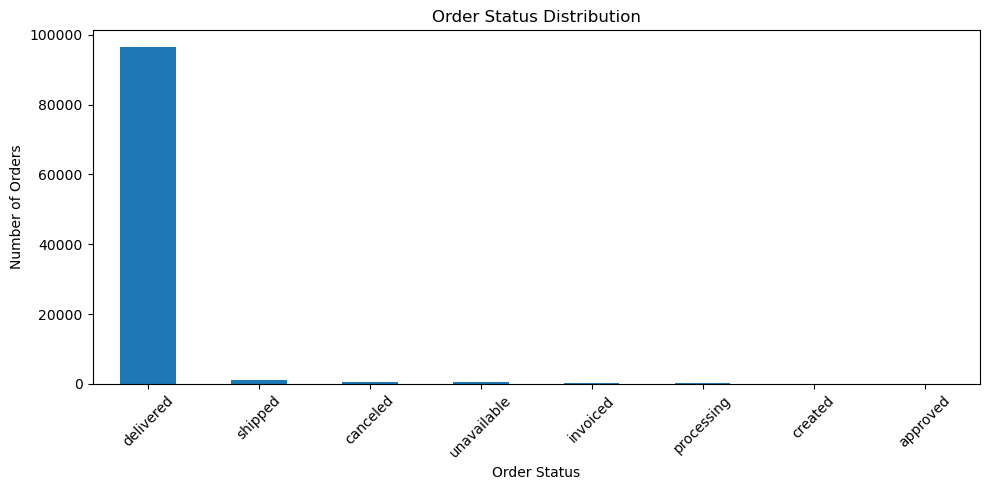

In [24]:
# ============================================================
# 18. UNIVARIATE ANALYSIS - ORDER STATUS
# ============================================================

orders = fe_datasets['Orders']

status_counts = orders['order_status'].value_counts()

plt.figure(figsize=(10, 5))
status_counts.plot(kind='bar')
plt.title('Order Status Distribution')
plt.xlabel('Order Status')
plt.ylabel('Number of Orders')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

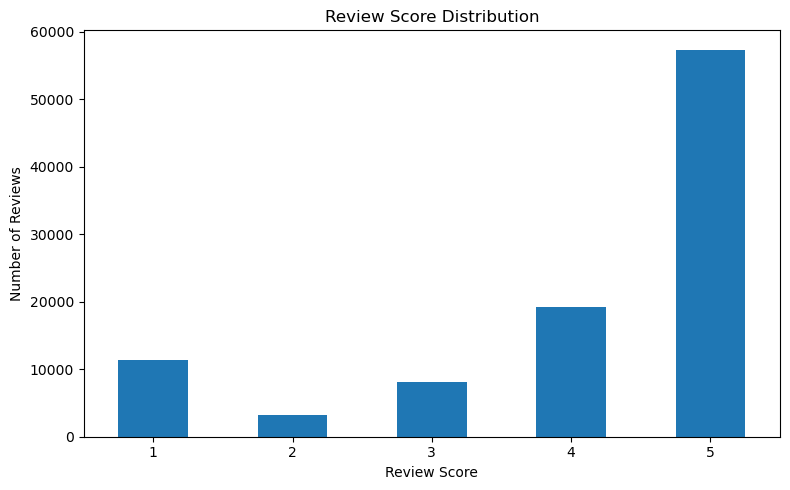

In [25]:
# ============================================================
# REVIEW SCORE DISTRIBUTION
# ============================================================

reviews = fe_datasets['Order Reviews']

review_counts = reviews['review_score'].value_counts().sort_index()

plt.figure(figsize=(8, 5))
review_counts.plot(kind='bar')
plt.title('Review Score Distribution')
plt.xlabel('Review Score')
plt.ylabel('Number of Reviews')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

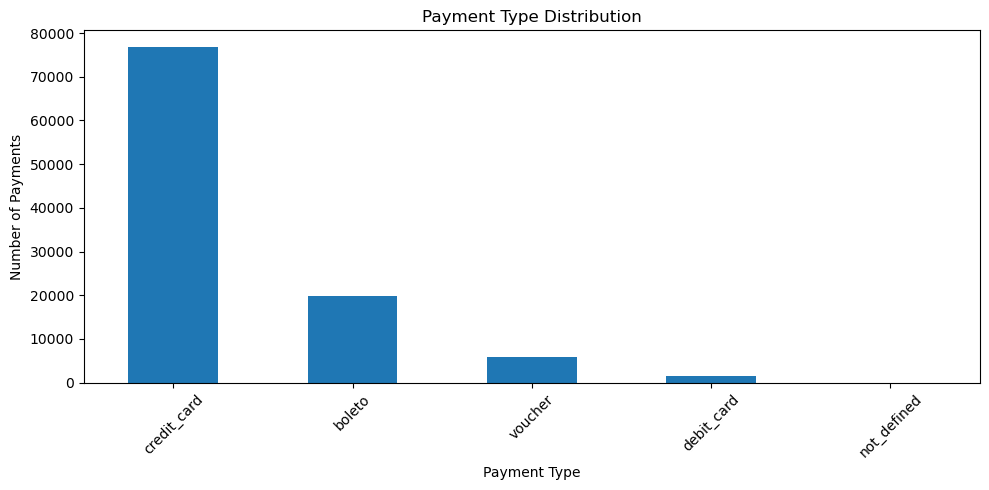

In [26]:
# ============================================================
# PAYMENT TYPE DISTRIBUTION
# ============================================================

payments = fe_datasets['Order Payments']

payment_counts = payments['payment_type'].value_counts()

plt.figure(figsize=(10, 5))
payment_counts.plot(kind='bar')
plt.title('Payment Type Distribution')
plt.xlabel('Payment Type')
plt.ylabel('Number of Payments')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

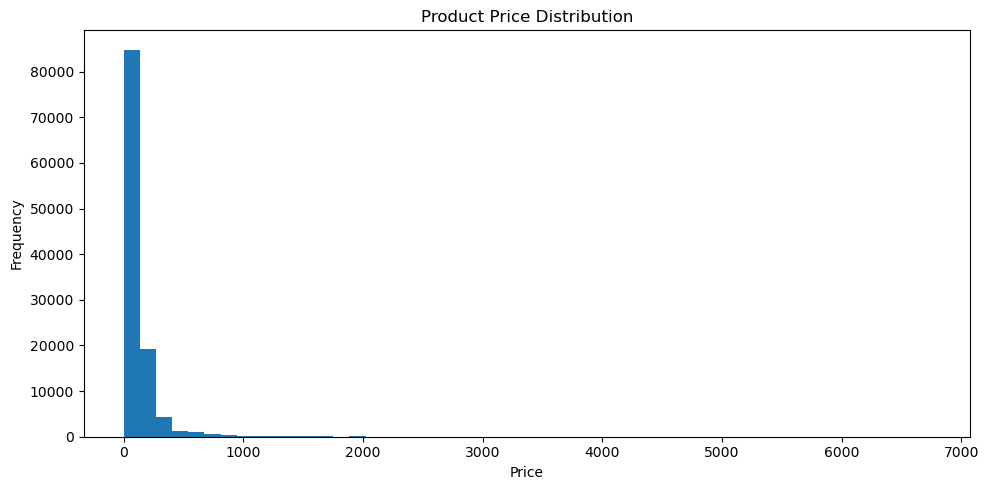

In [27]:
# ============================================================
# PRICE DISTRIBUTION
# ============================================================

order_items = fe_datasets['Order Items']

plt.figure(figsize=(10, 5))
plt.hist(order_items['price'], bins=50)
plt.title('Product Price Distribution')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

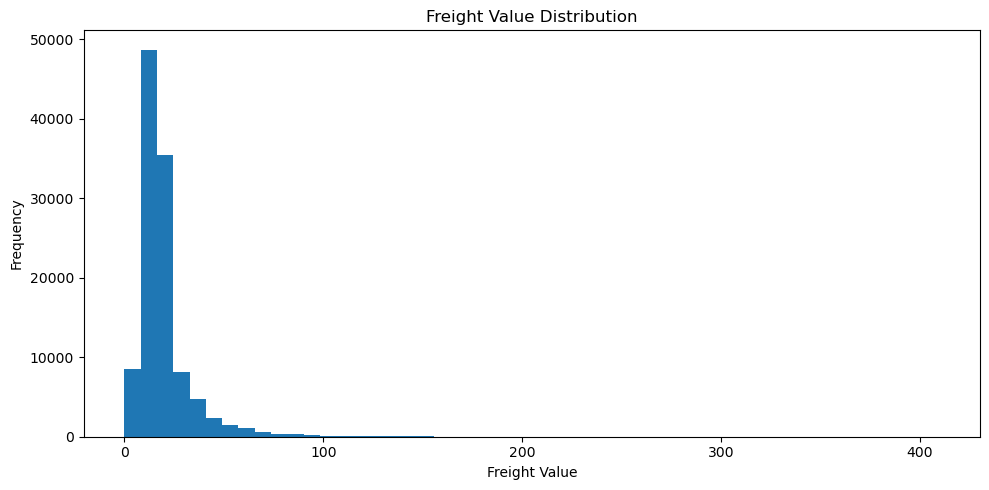

In [28]:
# ============================================================
# FREIGHT VALUE DISTRIBUTION
# ============================================================

plt.figure(figsize=(10, 5))
plt.hist(order_items['freight_value'], bins=50)
plt.title('Freight Value Distribution')
plt.xlabel('Freight Value')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

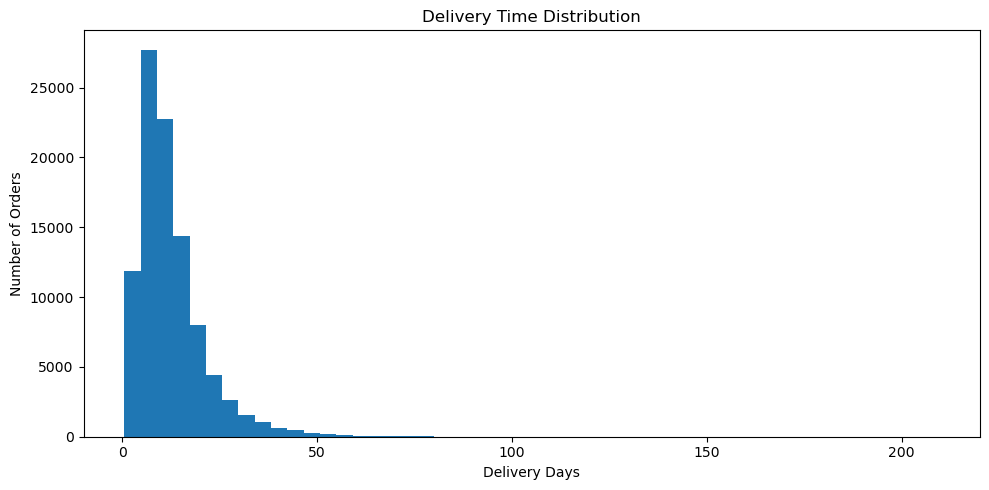

In [29]:
# ============================================================
# DELIVERY DAYS DISTRIBUTION
# ============================================================

plt.figure(figsize=(10, 5))
plt.hist(
    orders['delivery_days'].dropna(),
    bins=50
)
plt.title('Delivery Time Distribution')
plt.xlabel('Delivery Days')
plt.ylabel('Number of Orders')
plt.tight_layout()
plt.show()

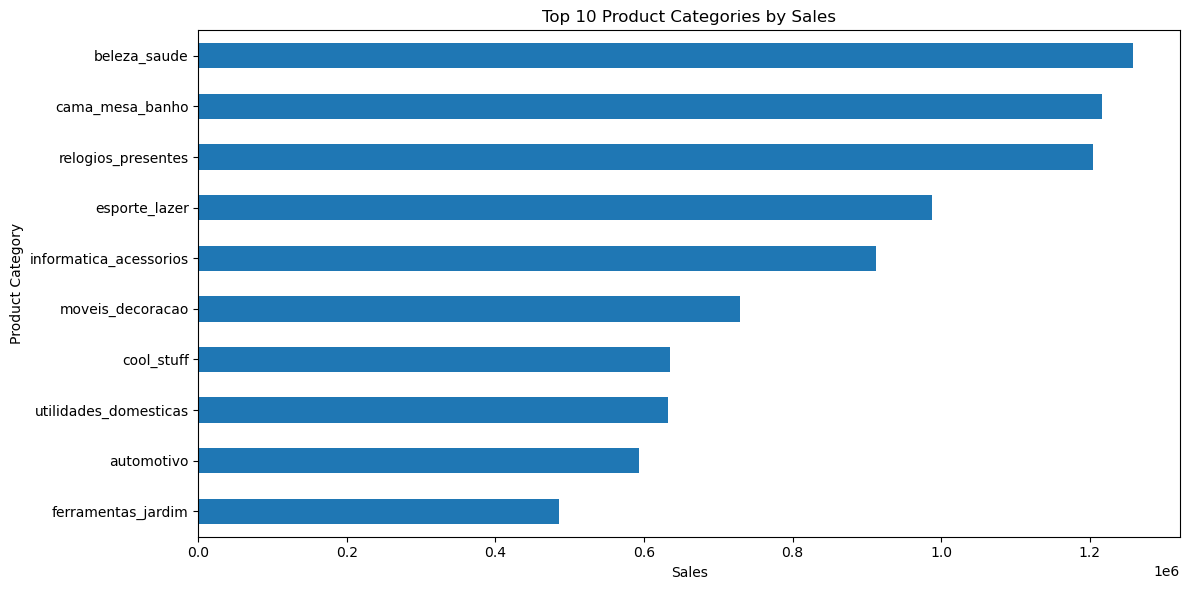

In [30]:
# ============================================================
# PRODUCT CATEGORY VS SALES
# ============================================================

products = fe_datasets['Products']

category_sales = (
    order_items
    .merge(
        products[['product_id', 'product_category_name']],
        on='product_id',
        how='left'
    )
    .groupby('product_category_name')['price']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12, 6))
category_sales.sort_values().plot(kind='barh')
plt.title('Top 10 Product Categories by Sales')
plt.xlabel('Sales')
plt.ylabel('Product Category')
plt.tight_layout()
plt.show()

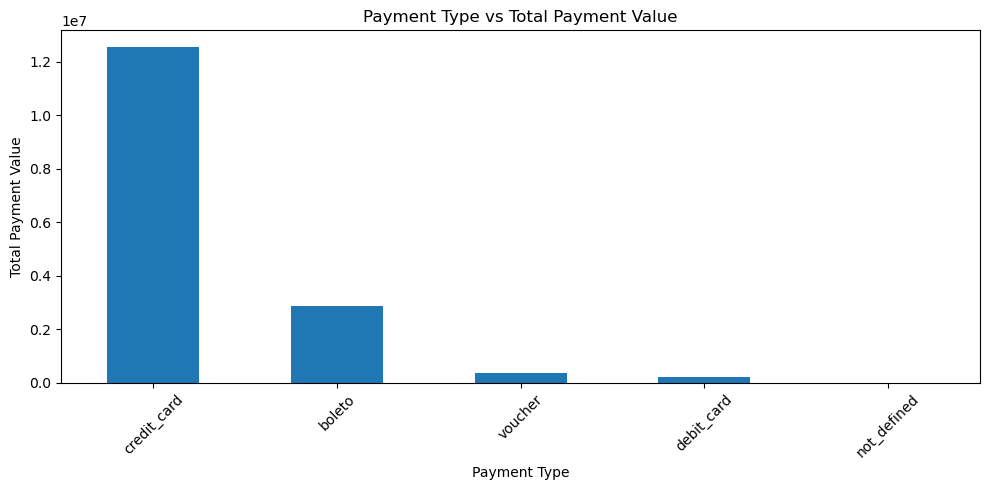

In [31]:
# ============================================================
# PAYMENT TYPE VS PAYMENT VALUE
# ============================================================

payment_value = (
    payments
    .groupby('payment_type')['payment_value']
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 5))
payment_value.plot(kind='bar')
plt.title('Payment Type vs Total Payment Value')
plt.xlabel('Payment Type')
plt.ylabel('Total Payment Value')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

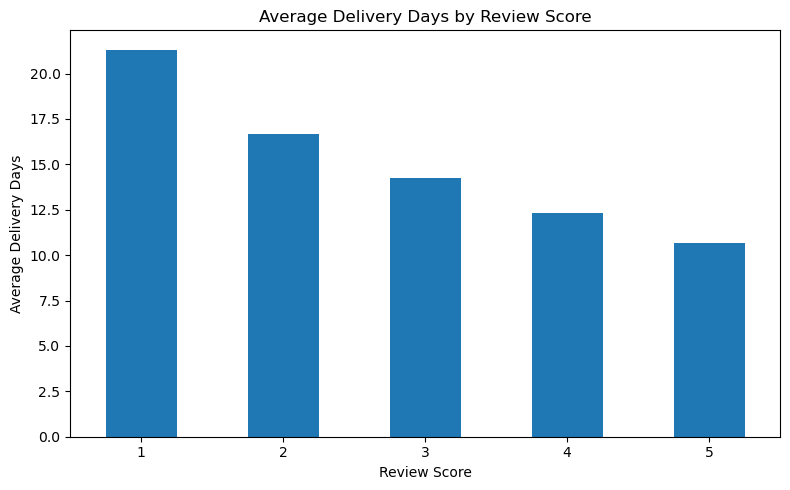

In [32]:
# ============================================================
# DELIVERY TIME VS REVIEW SCORE
# ============================================================

delivery_review = (
    orders[
        ['order_id', 'delivery_days']
    ]
    .merge(
        reviews[
            ['order_id', 'review_score']
        ],
        on='order_id',
        how='inner'
    )
)

review_delivery_avg = (
    delivery_review
    .groupby('review_score')['delivery_days']
    .mean()
)

plt.figure(figsize=(8, 5))
review_delivery_avg.plot(kind='bar')
plt.title('Average Delivery Days by Review Score')
plt.xlabel('Review Score')
plt.ylabel('Average Delivery Days')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

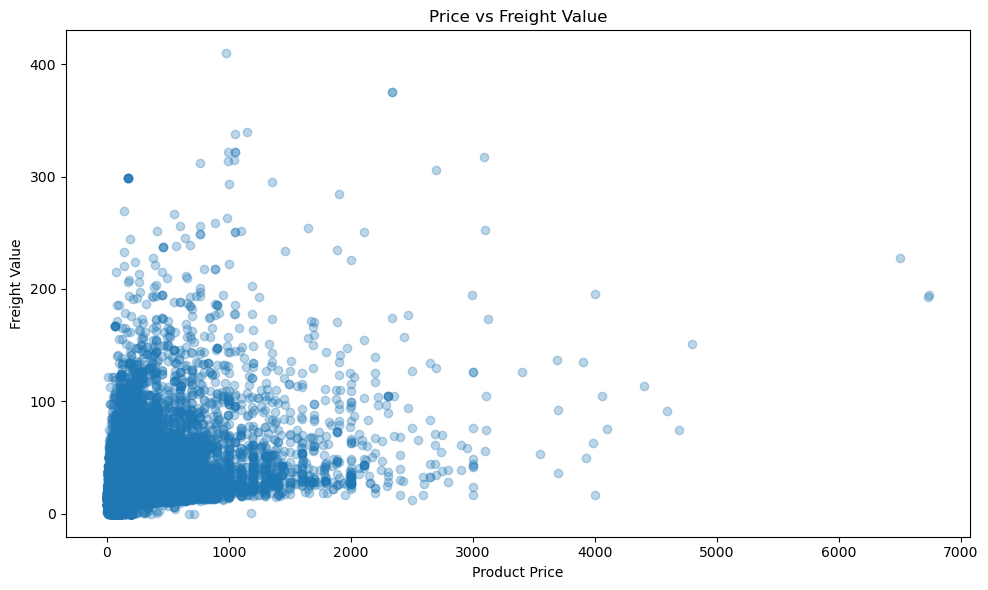

In [33]:
# ============================================================
# PRICE VS FREIGHT VALUE
# ============================================================

plt.figure(figsize=(10, 6))

plt.scatter(
    order_items['price'],
    order_items['freight_value'],
    alpha=0.3
)

plt.title('Price vs Freight Value')
plt.xlabel('Product Price')
plt.ylabel('Freight Value')
plt.tight_layout()
plt.show()

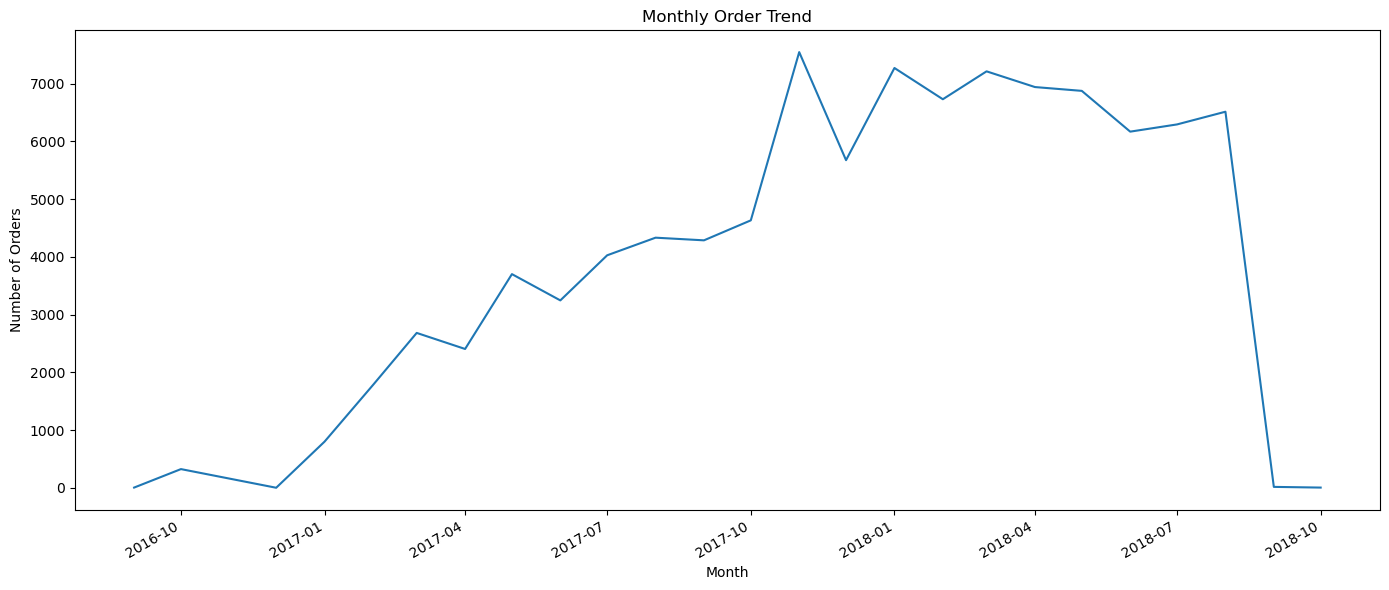

In [34]:
# ============================================================
# TIME SERIES - MONTHLY ORDERS
# ============================================================

orders['order_date'] = (
    orders['order_purchase_timestamp']
    .dt.to_period('M')
    .dt.to_timestamp()
)

monthly_orders = (
    orders
    .groupby('order_date')
    .size()
)

plt.figure(figsize=(14, 6))
monthly_orders.plot()
plt.title('Monthly Order Trend')
plt.xlabel('Month')
plt.ylabel('Number of Orders')
plt.tight_layout()
plt.show()

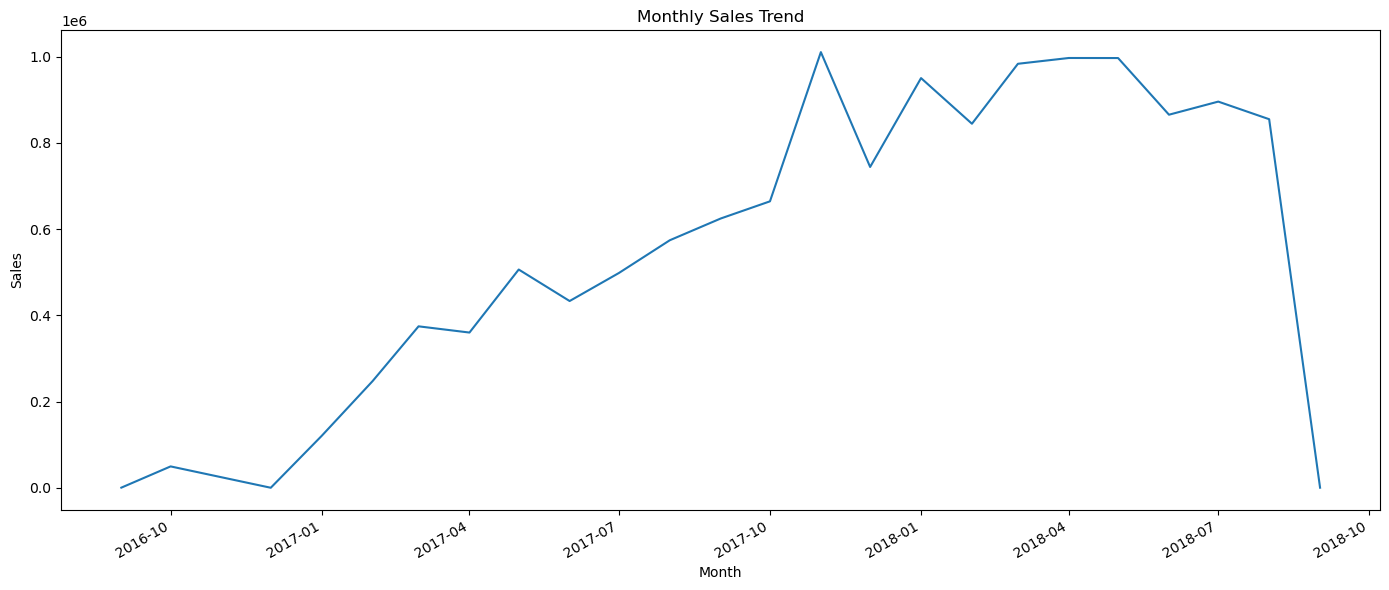

In [35]:
# ============================================================
# TIME SERIES - MONTHLY SALES
# ============================================================

order_item_dates = (
    order_items[
        ['order_id', 'price']
    ]
    .merge(
        orders[
            ['order_id', 'order_purchase_timestamp']
        ],
        on='order_id',
        how='left'
    )
)

order_item_dates['order_month'] = (
    order_item_dates['order_purchase_timestamp']
    .dt.to_period('M')
    .dt.to_timestamp()
)

monthly_sales = (
    order_item_dates
    .groupby('order_month')['price']
    .sum()
)

plt.figure(figsize=(14, 6))
monthly_sales.plot()
plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Sales')
plt.tight_layout()
plt.show()

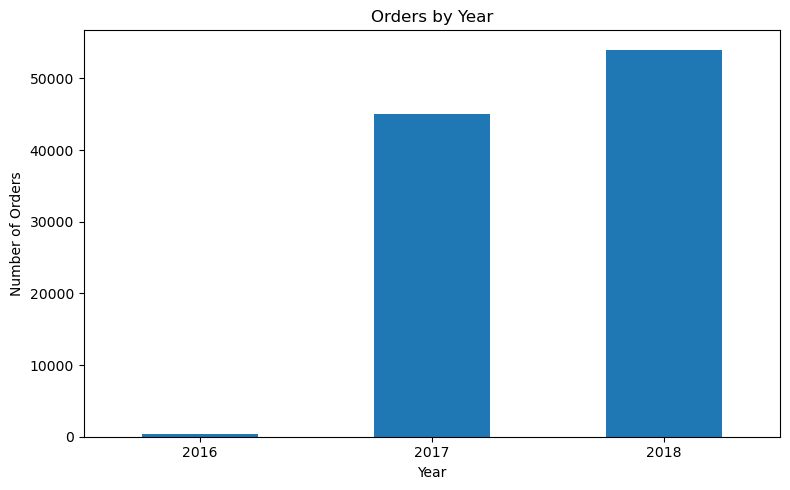

In [36]:
# ============================================================
# YEARLY ORDER TREND
# ============================================================

yearly_orders = (
    orders
    .groupby('order_year')
    .size()
)

plt.figure(figsize=(8, 5))
yearly_orders.plot(kind='bar')
plt.title('Orders by Year')
plt.xlabel('Year')
plt.ylabel('Number of Orders')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

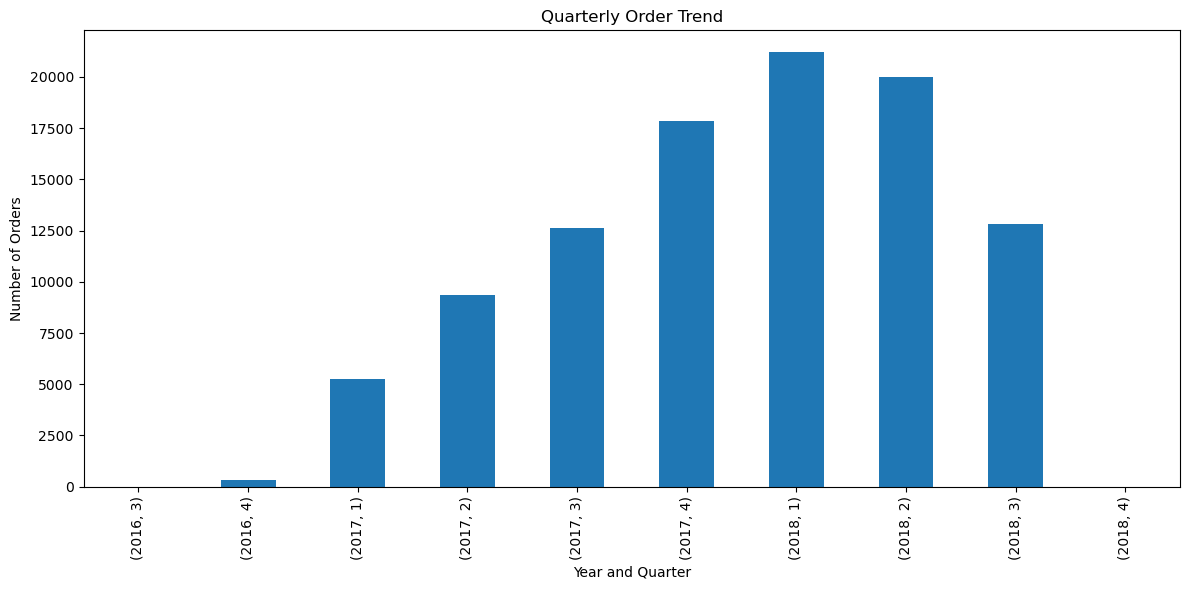

In [37]:
# ============================================================
# QUARTERLY ORDER TREND
# ============================================================

quarterly_orders = (
    orders
    .groupby(['order_year', 'order_quarter'])
    .size()
)

quarterly_orders.plot(kind='bar', figsize=(12, 6))

plt.title('Quarterly Order Trend')
plt.xlabel('Year and Quarter')
plt.ylabel('Number of Orders')
plt.tight_layout()
plt.show()

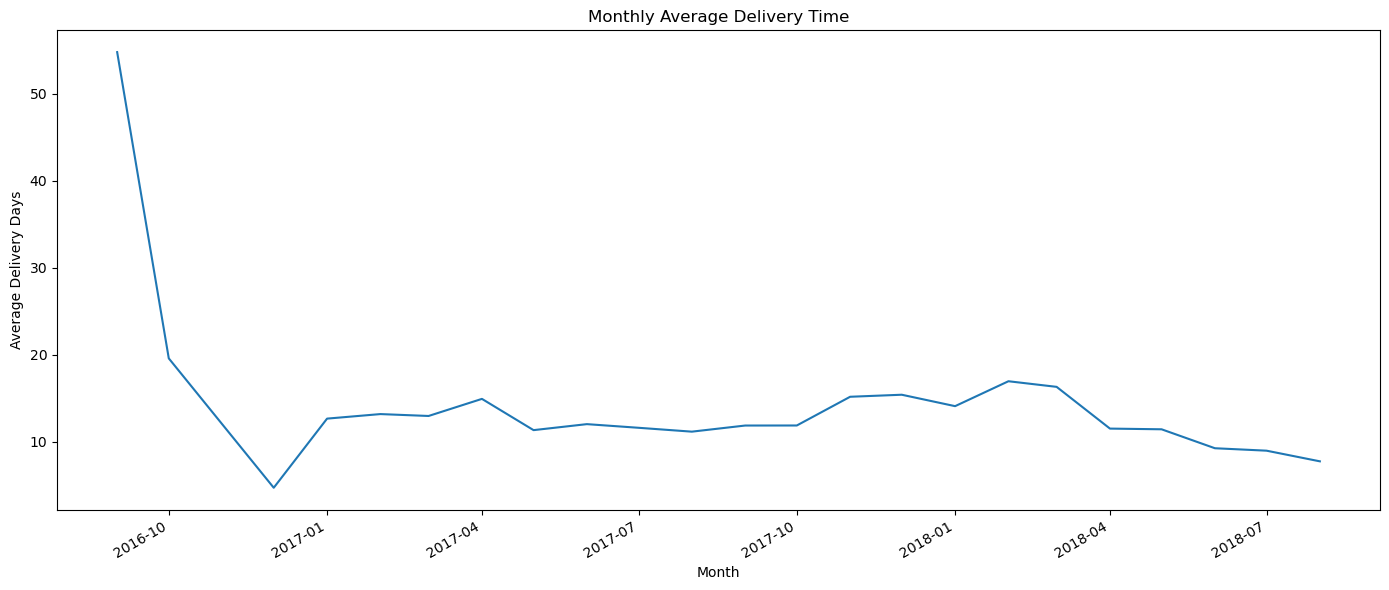

In [38]:
# ============================================================
# MONTHLY AVERAGE DELIVERY TIME
# ============================================================

monthly_delivery = (
    orders
    .groupby('order_date')['delivery_days']
    .mean()
)

plt.figure(figsize=(14, 6))
monthly_delivery.plot()
plt.title('Monthly Average Delivery Time')
plt.xlabel('Month')
plt.ylabel('Average Delivery Days')
plt.tight_layout()
plt.show()

In [39]:
# ============================================================
# CATEGORY + SALES + REVIEW SCORE
# ============================================================

category_data = (
    order_items[
        ['order_id', 'product_id', 'price']
    ]
    .merge(
        products[
            ['product_id', 'product_category_name']
        ],
        on='product_id',
        how='left'
    )
    .merge(
        reviews[
            ['order_id', 'review_score']
        ],
        on='order_id',
        how='left'
    )
)

category_analysis = (
    category_data
    .groupby('product_category_name')
    .agg(
        total_sales=('price', 'sum'),
        average_review=('review_score', 'mean'),
        number_of_orders=('order_id', 'nunique')
    )
    .sort_values(
        'total_sales',
        ascending=False
    )
    .head(10)
)

display(category_analysis)

,total_sales,average_review,number_of_orders
product_category_name,,,
beleza_saude,1263138.54,4.142768,8836
cama_mesa_banho,1231213.85,3.888810,10860
relogios_presentes,1206075.33,4.019160,5624
esporte_lazer,993656.51,4.107986,7720
informatica_acessorios,919640.54,3.930819,6689
moveis_decoracao,736282.47,3.903493,6449
cool_stuff,637258.51,4.146341,3632
utilidades_domesticas,634542.60,4.055019,5884
automotivo,594363.10,4.065512,3897


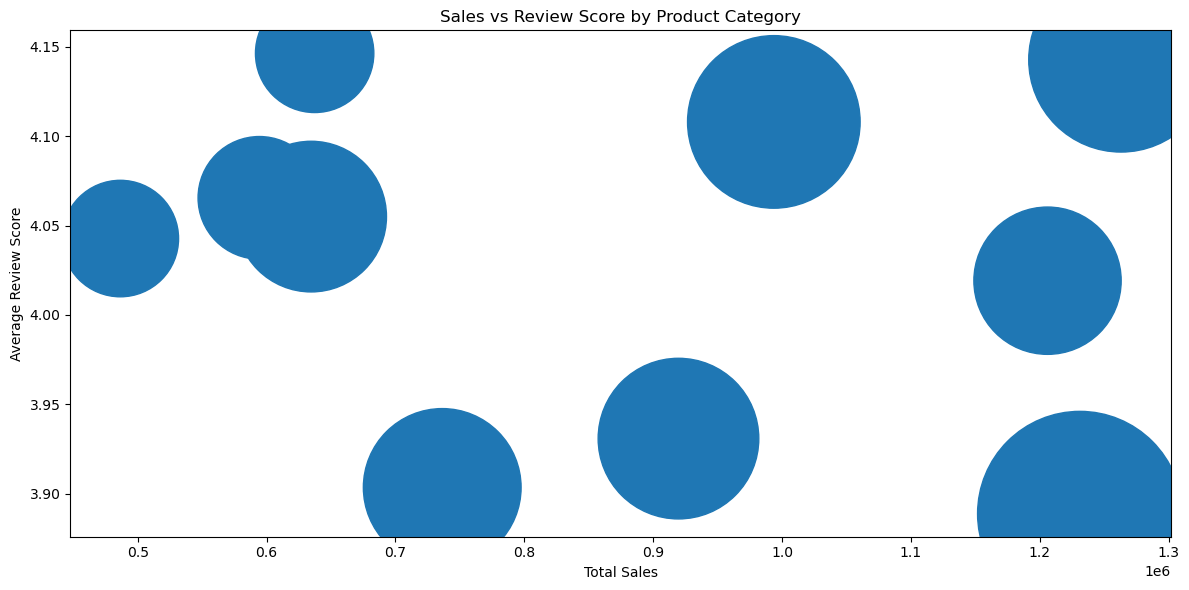

In [40]:
plt.figure(figsize=(12, 6))

plt.scatter(
    category_analysis['total_sales'],
    category_analysis['average_review'],
    s=category_analysis['number_of_orders'] * 2
)

plt.title('Sales vs Review Score by Product Category')
plt.xlabel('Total Sales')
plt.ylabel('Average Review Score')
plt.tight_layout()
plt.show()

In [41]:
# ============================================================
# DELIVERY + REVIEW + ORDER STATUS
# ============================================================

delivery_status_review = (
    orders[
        [
            'order_id',
            'order_status',
            'delivery_days'
        ]
    ]
    .merge(
        reviews[
            ['order_id', 'review_score']
        ],
        on='order_id',
        how='inner'
    )
)

status_review_analysis = (
    delivery_status_review
    .groupby('order_status')
    .agg(
        average_delivery_days=('delivery_days', 'mean'),
        average_review_score=('review_score', 'mean'),
        order_count=('order_id', 'nunique')
    )
)

display(status_review_analysis)

,average_delivery_days,average_review_score,order_count
order_status,,,
approved,NaN,2.500000,2
canceled,20.360006,1.811166,605
created,NaN,2.333333,3
delivered,12.522869,4.155717,95832
invoiced,NaN,1.661342,309
processing,NaN,1.277027,295
shipped,NaN,2.008629,1032
unavailable,NaN,1.530988,595


In [44]:
# ============================================================
# CORRELATION ANALYSIS - ORDER ITEMS
# ============================================================

item_corr = order_items[
    [
        'price',
        'freight_value',
        'total_item_value',
        'freight_percentage'
    ]
].corr()

display(item_corr)

,price,freight_value,total_item_value,freight_percentage
price,1.000000,0.414204,0.997151,-0.291402
freight_value,0.414204,1.000000,0.481681,0.088493
total_item_value,0.997151,0.481681,1.000000,-0.273234
freight_percentage,-0.291402,0.088493,-0.273234,1.000000


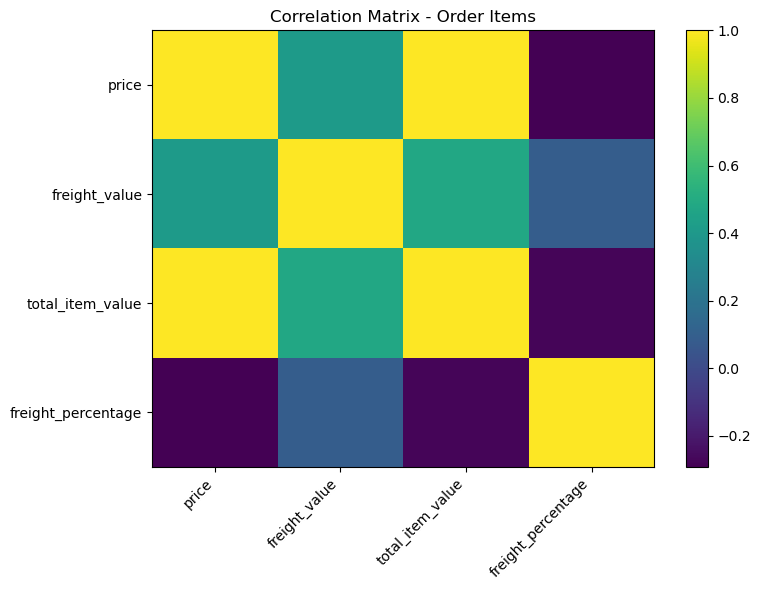

In [45]:
# ============================================================
# CORRELATION MATRIX
# ============================================================

plt.figure(figsize=(8, 6))

plt.imshow(
    item_corr,
    interpolation='nearest',
    aspect='auto'
)

plt.colorbar()

plt.xticks(
    range(len(item_corr.columns)),
    item_corr.columns,
    rotation=45,
    ha='right'
)

plt.yticks(
    range(len(item_corr.columns)),
    item_corr.columns
)

plt.title('Correlation Matrix - Order Items')

plt.tight_layout()
plt.show()

In [46]:
# ============================================================
# DELIVERY & REVIEW CORRELATION
# ============================================================

delivery_review_numeric = (
    orders[
        [
            'order_id',
            'delivery_days',
            'delivery_delay_days'
        ]
    ]
    .merge(
        reviews[
            [
                'order_id',
                'review_score'
            ]
        ],
        on='order_id',
        how='inner'
    )
)

delivery_corr = delivery_review_numeric[
    [
        'delivery_days',
        'delivery_delay_days',
        'review_score'
    ]
].corr()

display(delivery_corr)

,delivery_days,delivery_delay_days,review_score
delivery_days,1.000000,0.601111,-0.333804
delivery_delay_days,0.601111,1.000000,-0.266414
review_score,-0.333804,-0.266414,1.000000


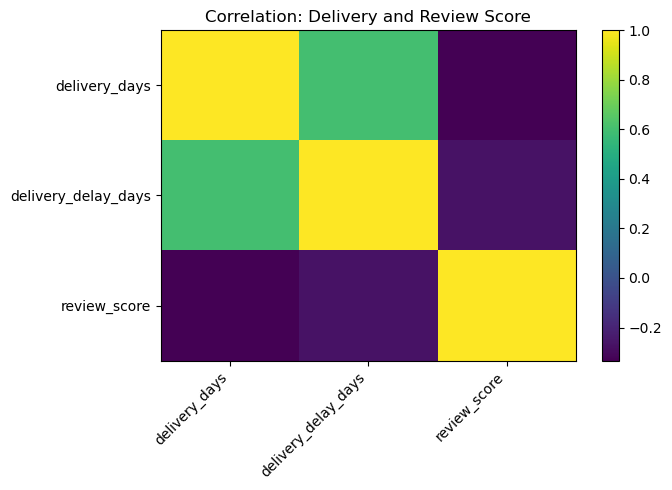

In [47]:
plt.figure(figsize=(7, 5))

plt.imshow(
    delivery_corr,
    interpolation='nearest',
    aspect='auto'
)

plt.colorbar()

plt.xticks(
    range(len(delivery_corr.columns)),
    delivery_corr.columns,
    rotation=45,
    ha='right'
)

plt.yticks(
    range(len(delivery_corr.columns)),
    delivery_corr.columns
)

plt.title('Correlation: Delivery and Review Score')

plt.tight_layout()
plt.show()

In [49]:
# ============================================================
# REFRESH FEATURE-ENGINEERED DATASETS
# ============================================================

orders = fe_datasets['Orders']
order_items = fe_datasets['Order Items']
payments = fe_datasets['Order Payments']
reviews = fe_datasets['Order Reviews']
products = fe_datasets['Products']

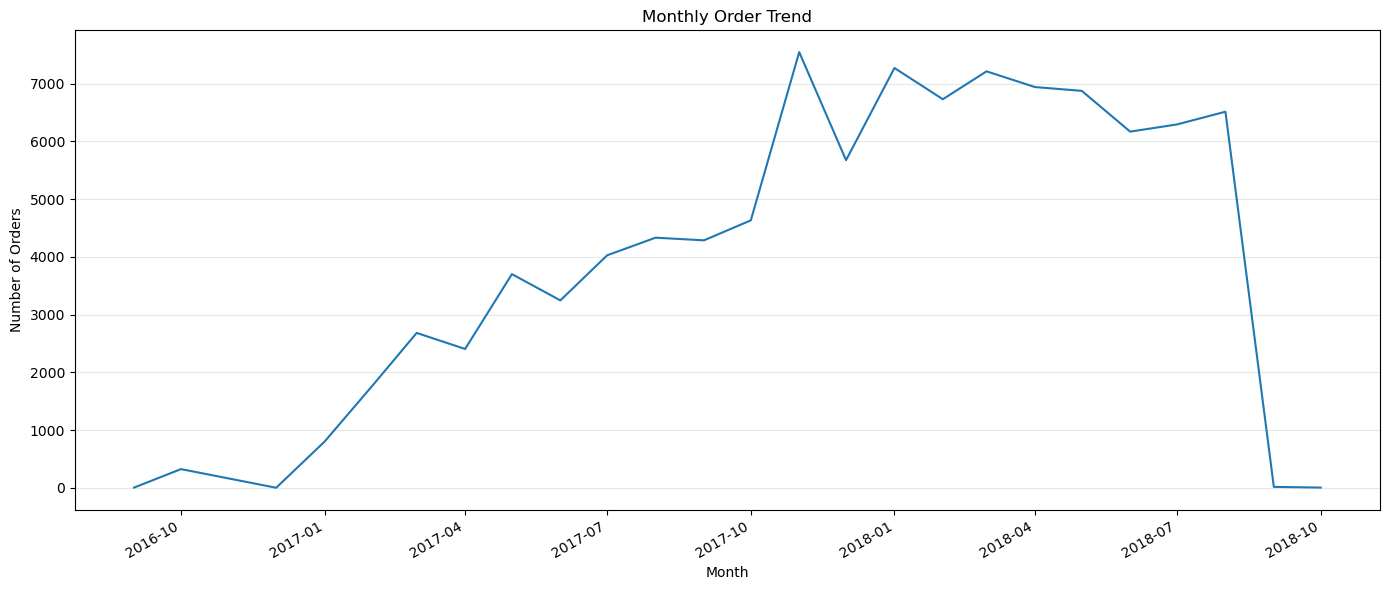

In [50]:
# ============================================================
# TREND ANALYSIS - MONTHLY ORDERS
# ============================================================

monthly_orders = (
    orders
    .groupby('order_date')
    .size()
)

plt.figure(figsize=(14, 6))

monthly_orders.plot()

plt.title('Monthly Order Trend')
plt.xlabel('Month')
plt.ylabel('Number of Orders')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

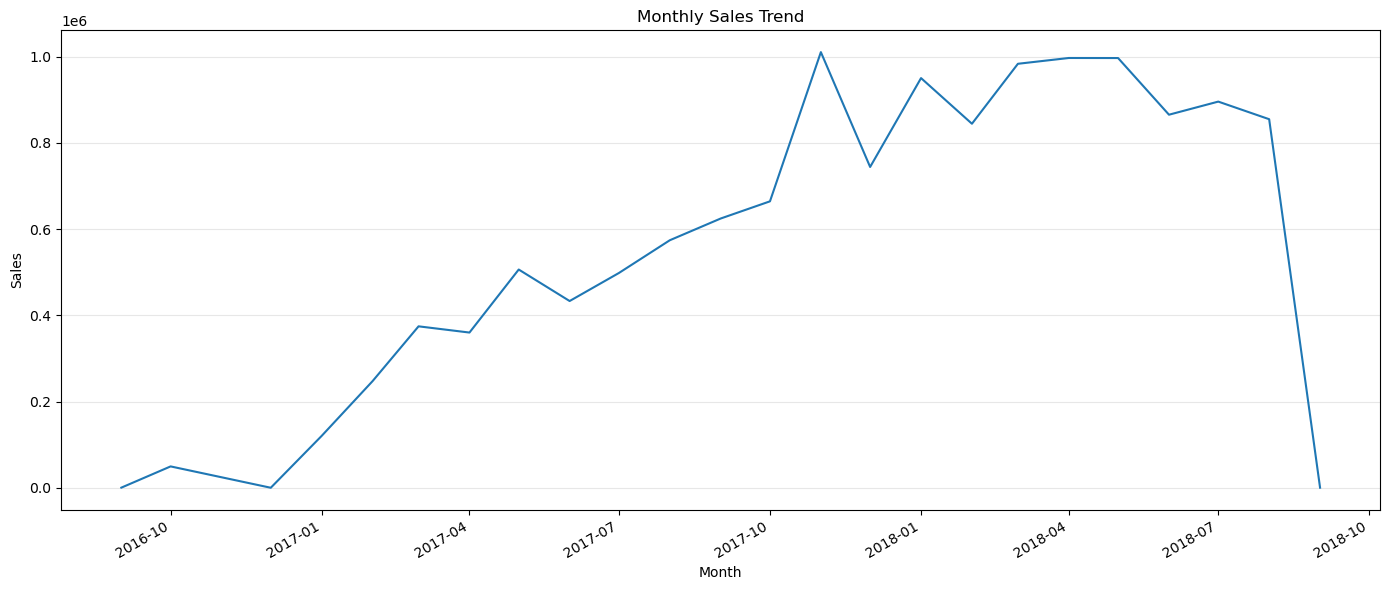

In [51]:
# ============================================================
# TREND ANALYSIS - MONTHLY SALES
# ============================================================

order_sales = (
    order_items[
        ['order_id', 'price']
    ]
    .merge(
        orders[
            ['order_id', 'order_purchase_timestamp']
        ],
        on='order_id',
        how='left'
    )
)

order_sales['order_month'] = (
    order_sales['order_purchase_timestamp']
    .dt.to_period('M')
    .dt.to_timestamp()
)

monthly_sales = (
    order_sales
    .groupby('order_month')['price']
    .sum()
)

plt.figure(figsize=(14, 6))

monthly_sales.plot()

plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Sales')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

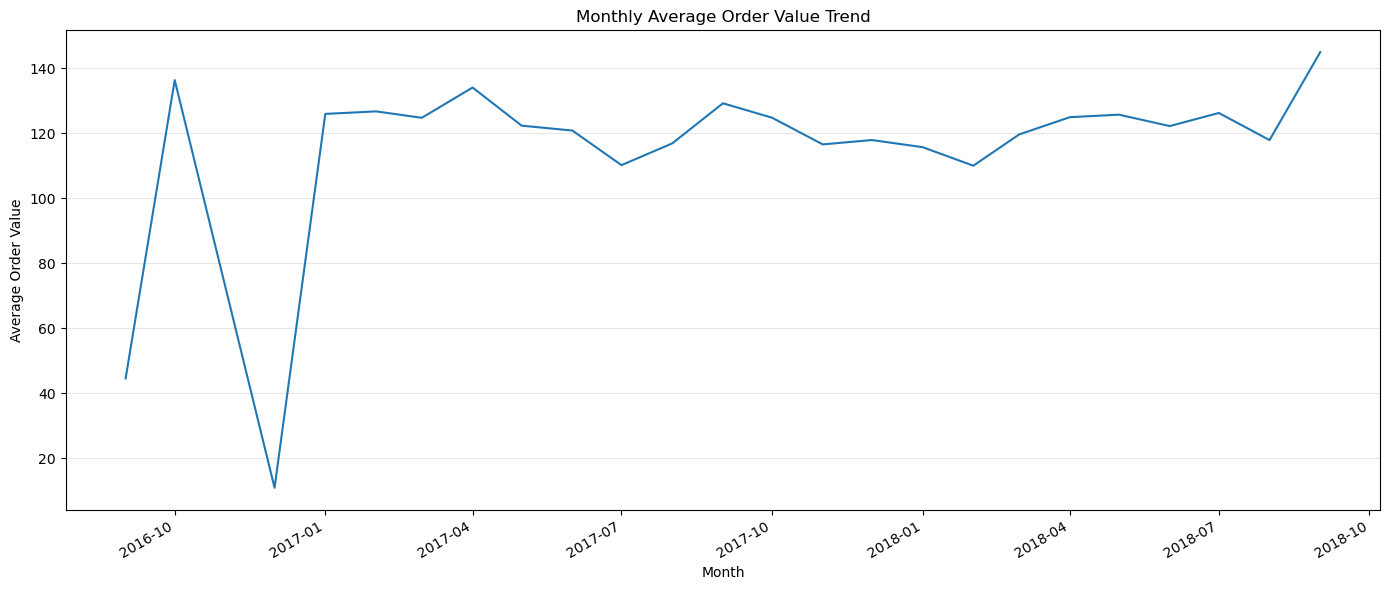

In [52]:
# ============================================================
# TREND ANALYSIS - AVERAGE ORDER VALUE
# ============================================================

monthly_aov = (
    order_sales
    .groupby('order_month')['price']
    .agg(['sum', 'count'])
)

monthly_aov['average_order_value'] = (
    monthly_aov['sum'] /
    monthly_aov['count']
)

plt.figure(figsize=(14, 6))

monthly_aov['average_order_value'].plot()

plt.title('Monthly Average Order Value Trend')
plt.xlabel('Month')
plt.ylabel('Average Order Value')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

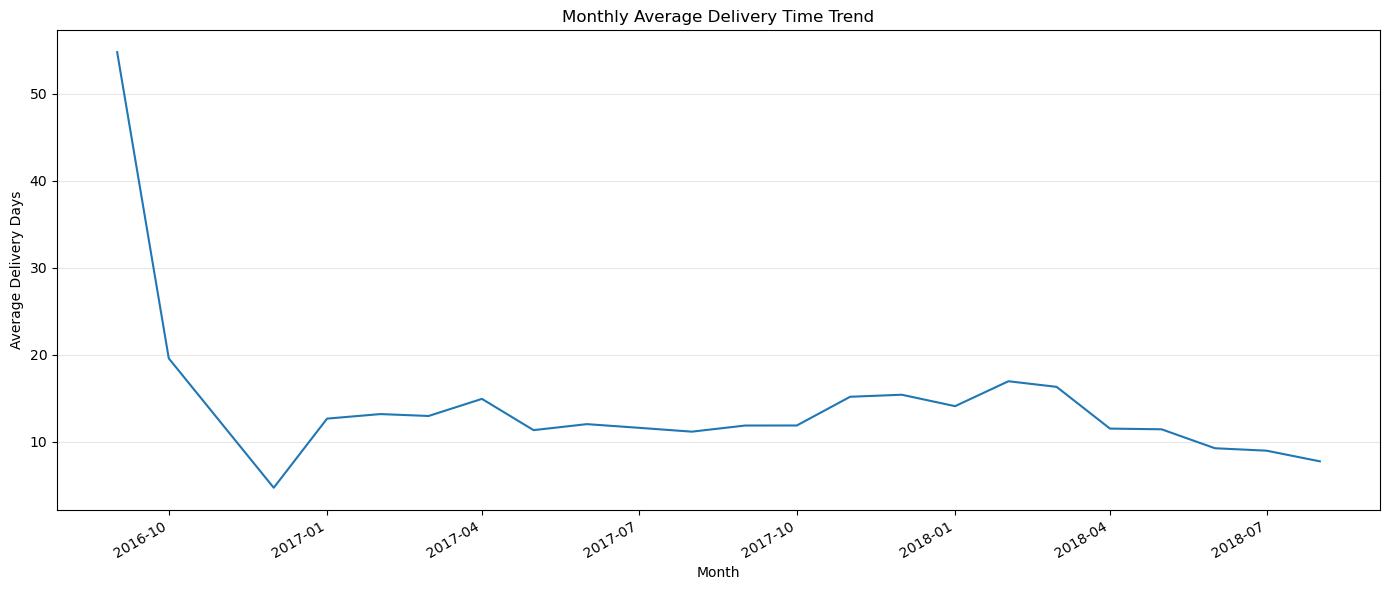

In [53]:
# ============================================================
# TREND ANALYSIS - DELIVERY TIME
# ============================================================

monthly_delivery = (
    orders
    .groupby('order_date')['delivery_days']
    .mean()
)

plt.figure(figsize=(14, 6))

monthly_delivery.plot()

plt.title('Monthly Average Delivery Time Trend')
plt.xlabel('Month')
plt.ylabel('Average Delivery Days')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

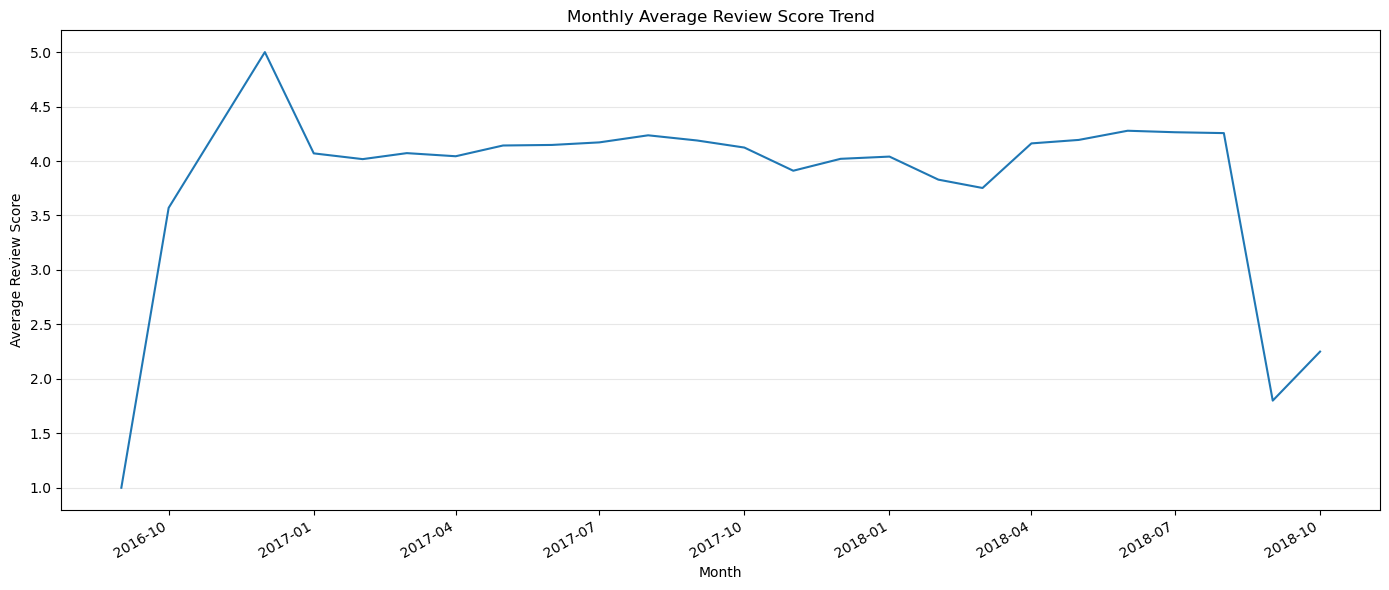

In [54]:
# ============================================================
# TREND ANALYSIS - REVIEW SCORE
# ============================================================

review_trend = (
    reviews
    .merge(
        orders[
            ['order_id', 'order_purchase_timestamp']
        ],
        on='order_id',
        how='inner'
    )
)

review_trend['order_month'] = (
    review_trend['order_purchase_timestamp']
    .dt.to_period('M')
    .dt.to_timestamp()
)

monthly_review = (
    review_trend
    .groupby('order_month')['review_score']
    .mean()
)

plt.figure(figsize=(14, 6))

monthly_review.plot()

plt.title('Monthly Average Review Score Trend')
plt.xlabel('Month')
plt.ylabel('Average Review Score')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

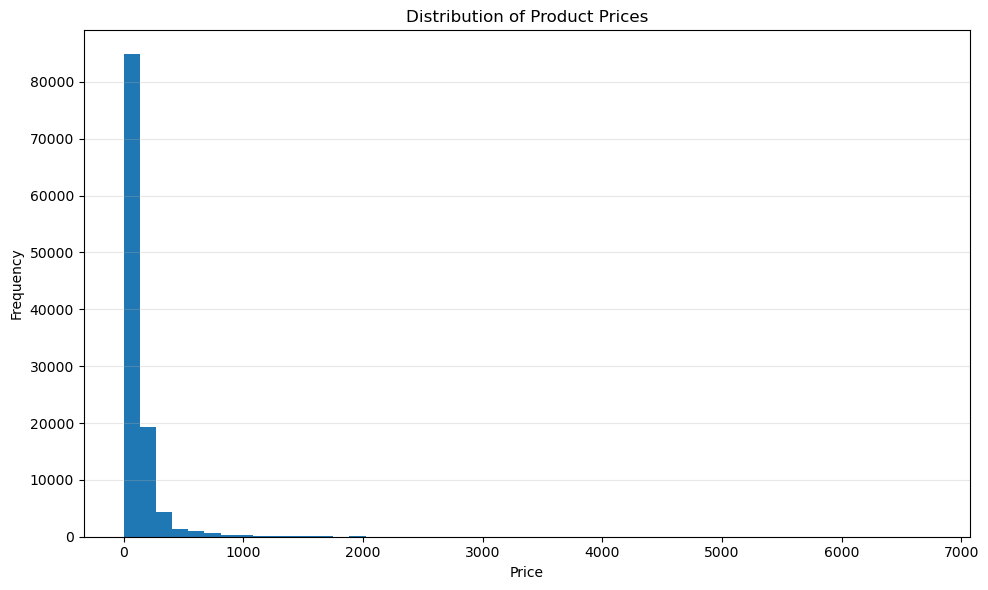

In [55]:
# ============================================================
# DISTRIBUTION ANALYSIS - PRICE
# ============================================================

plt.figure(figsize=(10, 6))

plt.hist(
    order_items['price'].dropna(),
    bins=50
)

plt.title('Distribution of Product Prices')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

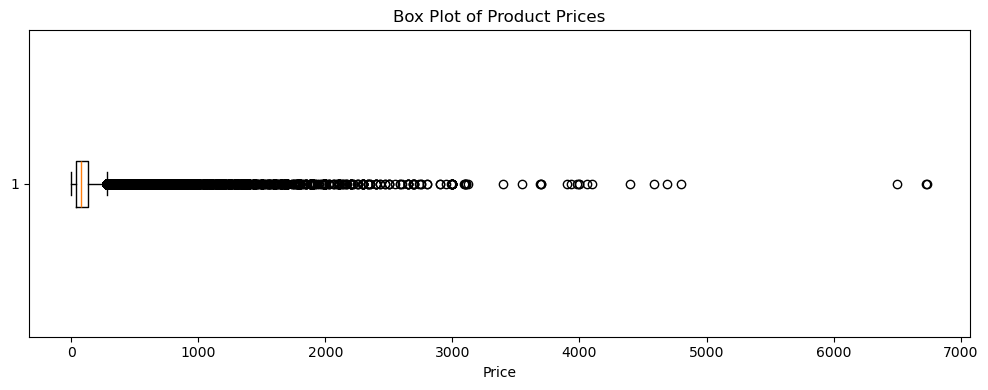

In [56]:
# ============================================================
# PRICE OUTLIER ANALYSIS
# ============================================================

plt.figure(figsize=(10, 4))

plt.boxplot(
    order_items['price'].dropna(),
    vert=False
)

plt.title('Box Plot of Product Prices')
plt.xlabel('Price')
plt.tight_layout()
plt.show()

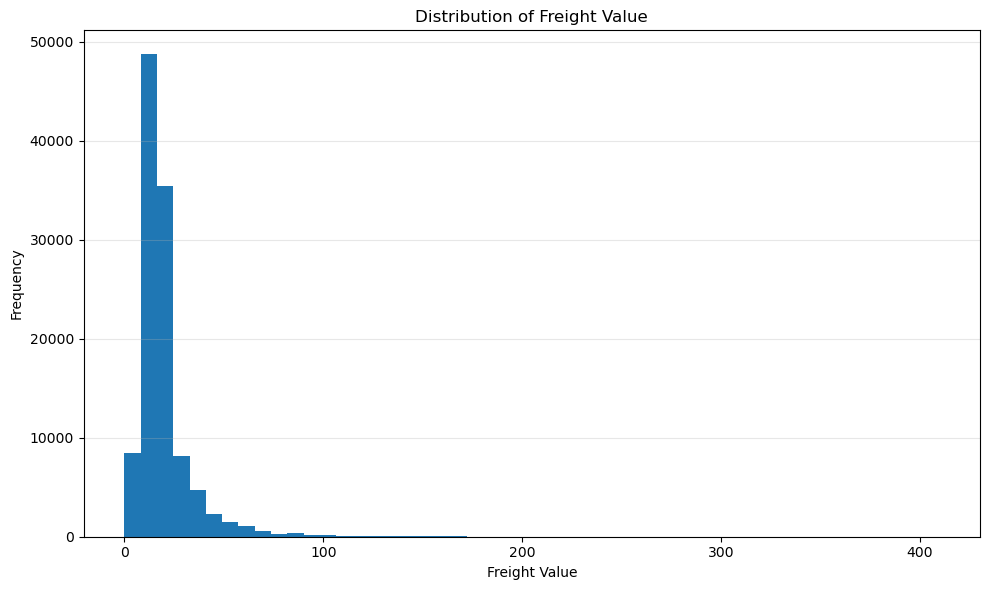

In [57]:
# ============================================================
# DISTRIBUTION ANALYSIS - FREIGHT
# ============================================================

plt.figure(figsize=(10, 6))

plt.hist(
    order_items['freight_value'].dropna(),
    bins=50
)

plt.title('Distribution of Freight Value')
plt.xlabel('Freight Value')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

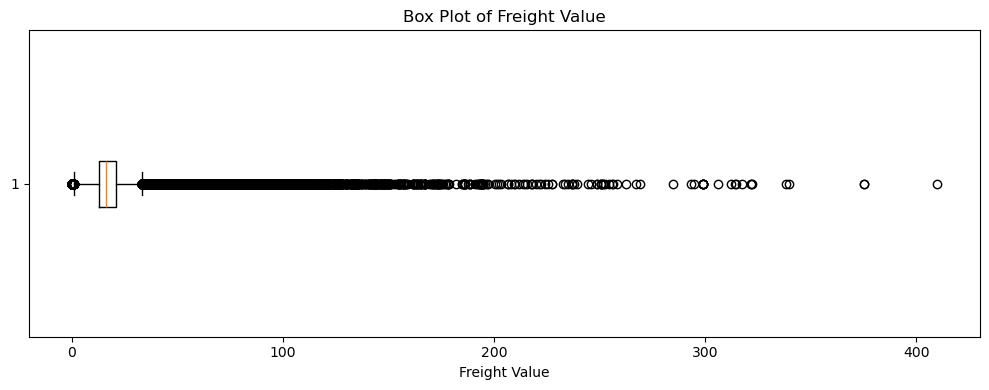

In [58]:
# ============================================================
# FREIGHT OUTLIER ANALYSIS
# ============================================================

plt.figure(figsize=(10, 4))

plt.boxplot(
    order_items['freight_value'].dropna(),
    vert=False
)

plt.title('Box Plot of Freight Value')
plt.xlabel('Freight Value')
plt.tight_layout()
plt.show()

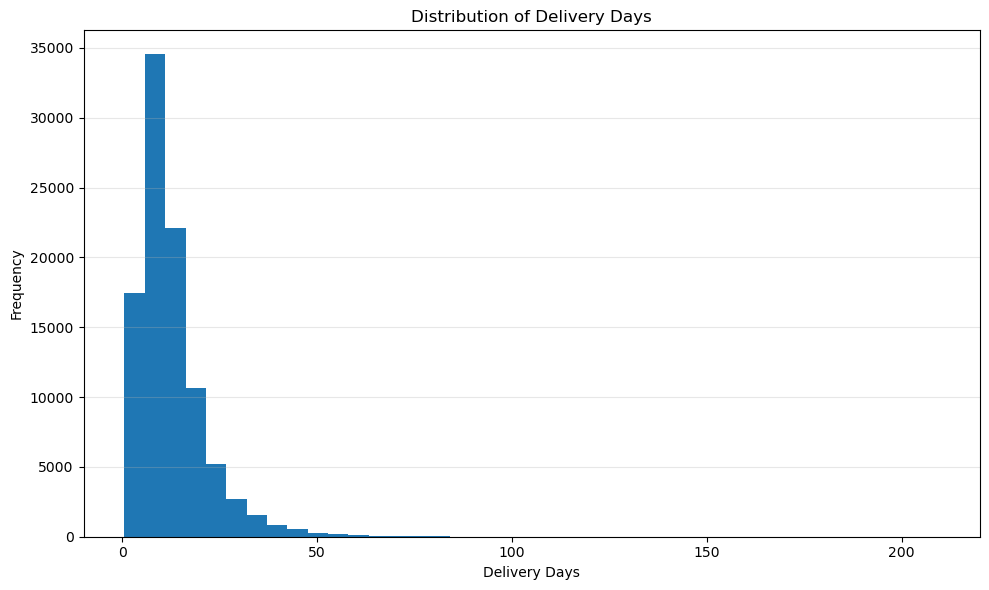

In [59]:
# ============================================================
# DISTRIBUTION ANALYSIS - DELIVERY DAYS
# ============================================================

plt.figure(figsize=(10, 6))

plt.hist(
    orders['delivery_days'].dropna(),
    bins=40
)

plt.title('Distribution of Delivery Days')
plt.xlabel('Delivery Days')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

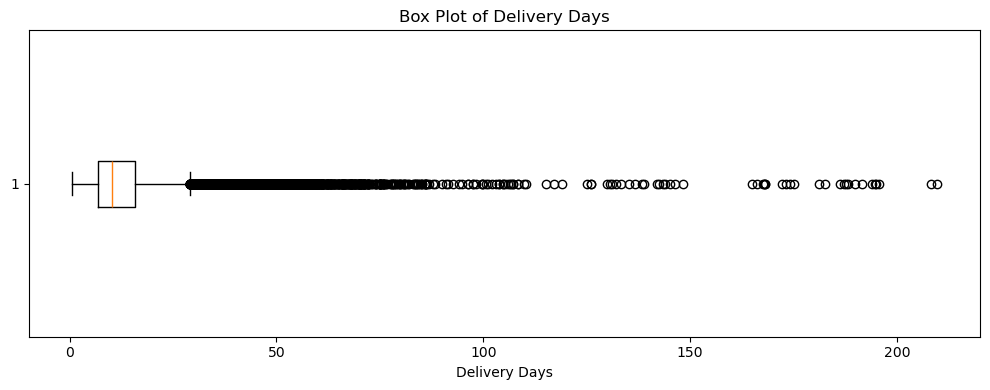

In [60]:
# ============================================================
# DELIVERY DAYS OUTLIER ANALYSIS
# ============================================================

plt.figure(figsize=(10, 4))

plt.boxplot(
    orders['delivery_days'].dropna(),
    vert=False
)

plt.title('Box Plot of Delivery Days')
plt.xlabel('Delivery Days')
plt.tight_layout()
plt.show()

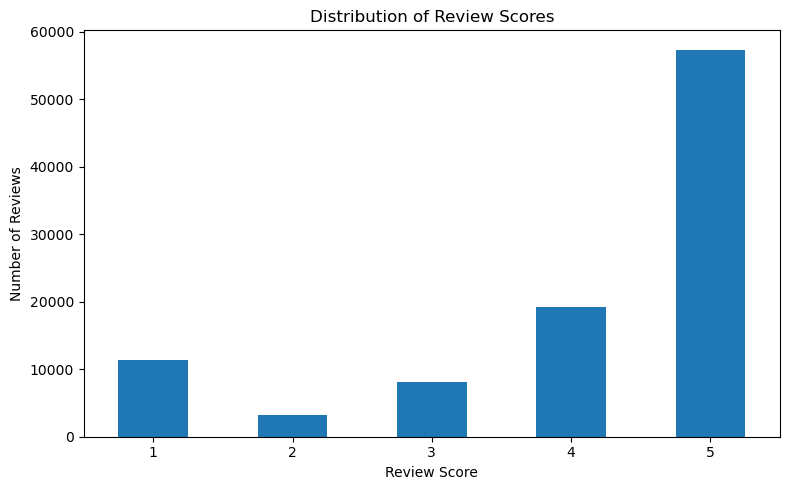

In [61]:
# ============================================================
# DISTRIBUTION ANALYSIS - REVIEW SCORE
# ============================================================

review_distribution = (
    reviews['review_score']
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(8, 5))

review_distribution.plot(kind='bar')

plt.title('Distribution of Review Scores')
plt.xlabel('Review Score')
plt.ylabel('Number of Reviews')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

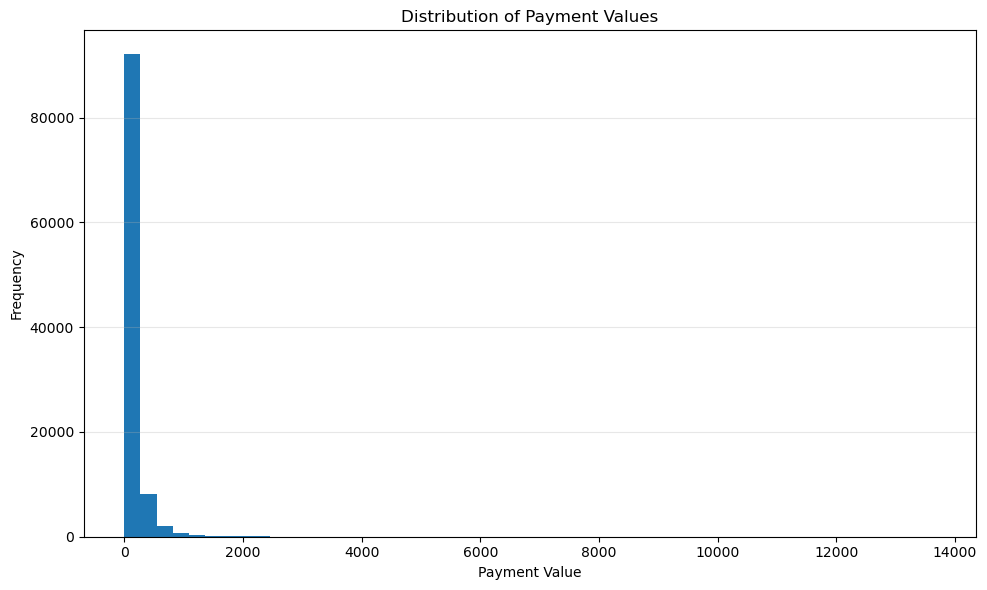

In [62]:
# ============================================================
# DISTRIBUTION ANALYSIS - PAYMENT VALUE
# ============================================================

plt.figure(figsize=(10, 6))

plt.hist(
    payments['payment_value'].dropna(),
    bins=50
)

plt.title('Distribution of Payment Values')
plt.xlabel('Payment Value')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

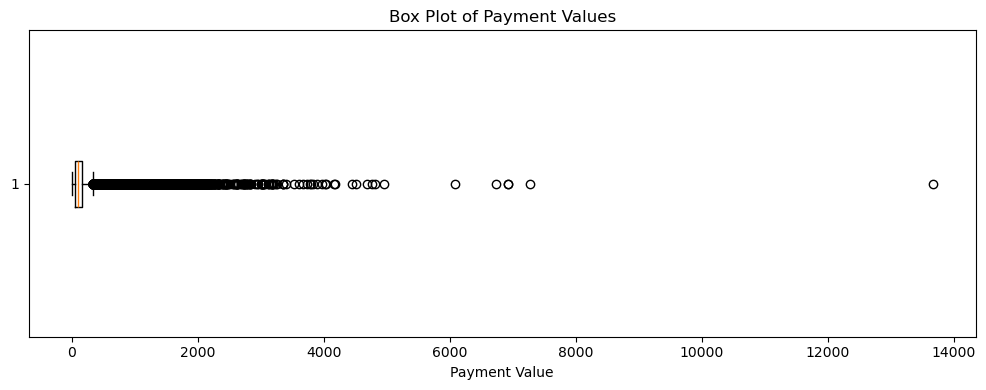

In [63]:
# ============================================================
# PAYMENT VALUE OUTLIER ANALYSIS
# ============================================================

plt.figure(figsize=(10, 4))

plt.boxplot(
    payments['payment_value'].dropna(),
    vert=False
)

plt.title('Box Plot of Payment Values')
plt.xlabel('Payment Value')
plt.tight_layout()
plt.show()

In [64]:
# ============================================================
# NUMERICAL DISTRIBUTION SUMMARY
# ============================================================

distribution_summary = pd.DataFrame({
    'Price': order_items['price'],
    'Freight Value': order_items['freight_value'],
    'Total Item Value': order_items['total_item_value'],
    'Freight Percentage': order_items['freight_percentage'],
    'Delivery Days': orders['delivery_days'],
    'Review Score': reviews['review_score'],
    'Payment Value': payments['payment_value']
})

display(
    distribution_summary.describe().T
)

,count,mean,std,min,25%,50%,75%,max
Price,112650.0,120.653739,183.633928,0.850000,39.900000,74.990000,134.900000,6735.000000
Freight Value,112650.0,19.990320,15.806405,0.000000,13.080000,16.260000,21.150000,409.680000
Total Item Value,112650.0,140.644059,190.724394,6.080000,55.220000,92.320000,157.937500,6929.310000
Freight Percentage,112650.0,32.086355,34.989368,0.000000,13.403366,23.135624,39.303621,2623.529412
Delivery Days,96476.0,12.558702,9.546530,0.533414,6.766403,10.217755,15.720327,209.628611
Review Score,99224.0,4.086421,1.347579,1.000000,4.000000,5.000000,5.000000,5.000000
Payment Value,103886.0,154.100380,217.494064,0.000000,56.790000,100.000000,171.837500,13664.080000


In [65]:
# ============================================================
# SKEWNESS ANALYSIS
# ============================================================

skewness = distribution_summary.skew(
    numeric_only=True
)

display(
    skewness.sort_values(ascending=False)
)

Freight Percentage    11.786514
Payment Value          9.254010
Price                  7.923208
Total Item Value       7.686087
Freight Value          5.639870
Delivery Days          3.832817
Review Score          -1.364386
dtype: float64

In [66]:
from sqlalchemy import create_engine, text

In [2]:
from sqlalchemy import create_engine, text
from urllib.parse import quote_plus

username = "root"
password = "Ammu@181296"
host = "localhost"
port = 3306
database = "olist_ecommerce"

encoded_password = quote_plus(password)

engine = create_engine(
    f"mysql+pymysql://{username}:{encoded_password}@{host}:{port}/{database}"
)

In [3]:
with engine.connect() as connection:
    result = connection.execute(text("SELECT DATABASE();"))
    print(result.fetchone())

('olist_ecommerce',)


In [82]:
cleaned_datasets.keys()

dict_keys(['Customers', 'Orders', 'Order Items', 'Order Payments', 'Order Reviews', 'Products', 'Sellers', 'Geolocation', 'Category Translation'])

In [83]:
for name, df in cleaned_datasets.items():
    print(name, df.shape)

Customers (99441, 5)
Orders (99441, 8)
Order Items (112650, 7)
Order Payments (103886, 5)
Order Reviews (99224, 7)
Products (32951, 9)
Sellers (3095, 4)
Geolocation (738332, 5)
Category Translation (71, 2)


In [85]:
customers = cleaned_datasets['Customers']

customers.to_sql(
    'customers',
    con=engine,
    if_exists='replace',
    index=False
)

print("Customers loaded:", len(customers))

Customers loaded: 99441


In [86]:
products = cleaned_datasets['Products']

products.to_sql(
    'products',
    con=engine,
    if_exists='replace',
    index=False
)

print("Products loaded:", len(products))

Products loaded: 32951


In [87]:
sellers = cleaned_datasets['Sellers']

sellers.to_sql(
    'sellers',
    con=engine,
    if_exists='replace',
    index=False
)

print("Sellers loaded:", len(sellers))

Sellers loaded: 3095


In [88]:
sellers = cleaned_datasets['Sellers']

sellers.to_sql(
    'sellers',
    con=engine,
    if_exists='replace',
    index=False
)

print("Sellers loaded:", len(sellers))

Sellers loaded: 3095


In [89]:
category_translation = cleaned_datasets['Category Translation']

category_translation.to_sql(
    'category_translation',
    con=engine,
    if_exists='replace',
    index=False
)

print("Category Translation loaded:", len(category_translation))

Category Translation loaded: 71


In [90]:
orders = cleaned_datasets['Orders']

orders.to_sql(
    'orders',
    con=engine,
    if_exists='replace',
    index=False
)

print("Orders loaded:", len(orders))

Orders loaded: 99441


In [91]:
order_items = cleaned_datasets['Order Items']

order_items.to_sql(
    'order_items',
    con=engine,
    if_exists='replace',
    index=False
)

print("Order Items loaded:", len(order_items))

Order Items loaded: 112650


In [92]:
order_payments = cleaned_datasets['Order Payments']

order_payments.to_sql(
    'order_payments',
    con=engine,
    if_exists='replace',
    index=False
)

print("Order Payments loaded:", len(order_payments))

Order Payments loaded: 103886


In [93]:
order_reviews = cleaned_datasets['Order Reviews']

order_reviews.to_sql(
    'order_reviews',
    con=engine,
    if_exists='replace',
    index=False
)

print("Order Reviews loaded:", len(order_reviews))

Order Reviews loaded: 99224


In [102]:
geolocation = cleaned_datasets['Geolocation']

geolocation.to_sql(
    'geolocation',
    con=engine,
    if_exists='replace',
    index=False
)

print("Geolocation loaded:", len(geolocation))

Geolocation loaded: 738332


In [100]:
with engine.connect() as connection:
    result = connection.execute(text("SHOW TABLES;"))

    for row in result:
        print(row[0])

category_translation
customers
geolocation
order_items
order_payments
order_reviews
orders
products
sellers


In [103]:
tables = [
    'customers',
    'orders',
    'order_items',
    'order_payments',
    'order_reviews',
    'products',
    'sellers',
    'geolocation',
    'category_translation'
]

for table in tables:
    query = text(f"SELECT COUNT(*) FROM `{table}`")

    with engine.connect() as connection:
        count = connection.execute(query).scalar()

    print(f"{table}: {count}")

customers: 99441
orders: 99441
order_items: 112650
order_payments: 103886
order_reviews: 99224
products: 32951
sellers: 3095
geolocation: 738332
category_translation: 71


In [104]:
for name, df in cleaned_datasets.items():
    print(name, len(df))

Customers 99441
Orders 99441
Order Items 112650
Order Payments 103886
Order Reviews 99224
Products 32951
Sellers 3095
Geolocation 738332
Category Translation 71


In [4]:
import pandas as pd

query = """
SELECT
    CASE
        WHEN o.order_delivered_customer_date > o.order_estimated_delivery_date
            THEN 'Late'
        ELSE 'On Time'
    END AS delivery_performance,
    
    r.review_score

FROM orders o
JOIN order_reviews r
    ON o.order_id = r.order_id

WHERE
    o.order_delivered_customer_date IS NOT NULL
"""

delivery_review_df = pd.read_sql(query, engine)

delivery_review_df.head()

,delivery_performance,review_score
0,On Time,5
1,On Time,4
2,On Time,5
3,On Time,4
4,On Time,5


In [5]:
delivery_review_df['delivery_performance'].value_counts()

delivery_performance
On Time    88658
Late        7701
Name: count, dtype: int64

In [6]:
delivery_review_df.groupby('delivery_performance')['review_score'].agg(
    ['count', 'mean', 'std']
)

,count,mean,std
delivery_performance,,,
Late,7701,2.566550,1.658240
On Time,88658,4.293578,1.147938


In [7]:
from scipy.stats import ttest_ind

# Separate review scores into two groups
on_time_scores = delivery_review_df[
    delivery_review_df['delivery_performance'] == 'On Time'
]['review_score']

late_scores = delivery_review_df[
    delivery_review_df['delivery_performance'] == 'Late'
]['review_score']

# Welch's independent two-sample T-test
t_statistic, p_value = ttest_ind(
    on_time_scores,
    late_scores,
    equal_var=False
)

print("T-statistic:", t_statistic)
print("P-value:", p_value)

T-statistic: 89.55081413351807
P-value: 0.0


In [8]:
import pandas as pd

query = """
SELECT
    p.product_category_name AS product_category,
    oi.order_id,
    SUM(oi.price) AS order_value
FROM order_items oi
JOIN products p
    ON oi.product_id = p.product_id
GROUP BY
    p.product_category_name,
    oi.order_id
"""

anova_df = pd.read_sql(query, engine)

anova_df.head()

,product_category,order_id,order_value
0,perfumaria,f30149f4a8882a08895b6a242aa0d612,101.65
1,automotivo,f5eda0ded77c1293b04c953138c8331d,129.90
2,cama_mesa_banho,0bf736fd0fd5169d60de3699fcbcf986,229.00
3,utilidades_domesticas,3aba44d8e554ab4bb8c09f6f78032ca8,58.90
4,utilidades_domesticas,6f0dfb5b5398b271cc6bbd9ee263530e,58.90


In [9]:
anova_df['product_category'].nunique()

73

In [10]:
anova_df['product_category'].value_counts().head(10)

product_category
cama_mesa_banho           10860
beleza_saude               8836
esporte_lazer              7720
informatica_acessorios     6689
moveis_decoracao           6449
utilidades_domesticas      5884
relogios_presentes         5624
telefonia                  4199
automotivo                 3897
brinquedos                 3886
Name: count, dtype: int64

In [11]:
from scipy.stats import f_oneway

# Remove missing categories
anova_df = anova_df.dropna(
    subset=['product_category', 'order_value']
)

# Create one group for each product category
groups = [
    group['order_value'].values
    for _, group in anova_df.groupby('product_category')
]

# One-Way ANOVA
f_statistic, p_value = f_oneway(*groups)

print("F-statistic:", f_statistic)
print("P-value:", p_value)

F-statistic: 153.92853382116843
P-value: 0.0


In [12]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

tukey_result = pairwise_tukeyhsd(
    endog=anova_df['order_value'],
    groups=anova_df['product_category'],
    alpha=0.05
)

print(tukey_result)

                                            Multiple Comparison of Means - Tukey HSD, FWER=0.05                                             
                    group1                                         group2                      meandiff  p-adj    lower      upper    reject
--------------------------------------------------------------------------------------------------------------------------------------------
                     agro_industria_e_comercio                                      alimentos  -333.2004    0.0  -405.9488  -260.4519   True
                     agro_industria_e_comercio                              alimentos_bebidas  -331.6491    0.0  -414.0478  -249.2505   True
                     agro_industria_e_comercio                                          artes   -278.704    0.0  -363.3412  -194.0668   True
                     agro_industria_e_comercio                             artes_e_artesanato  -319.6491    0.0  -502.9161   -136.382   True
             

In [13]:
# Convert Tukey results into a DataFrame
tukey_df = pd.DataFrame(
    data=tukey_result._results_table.data[1:],
    columns=tukey_result._results_table.data[0]
)

# Show only statistically significant comparisons
significant_pairs = tukey_df[
    tukey_df['reject'] == True
].copy()

significant_pairs

,group1,group2,meandiff,p-adj,lower,upper,reject
0,agro_industria_e_comercio,alimentos,-333.2004,0.0000,-405.9488,-260.4519,True
1,agro_industria_e_comercio,alimentos_bebidas,-331.6491,0.0000,-414.0478,-249.2505,True
2,agro_industria_e_comercio,artes,-278.7040,0.0000,-363.3412,-194.0668,True
3,agro_industria_e_comercio,artes_e_artesanato,-319.6491,0.0000,-502.9161,-136.3820,True
4,agro_industria_e_comercio,artigos_de_festas,-283.5145,0.0000,-429.6430,-137.3859,True
...,...,...,...,...,...,...,...
2620,sinalizacao_e_seguranca,telefonia_fixa,120.9387,0.0001,31.1654,210.7120,True
2623,tablets_impressao_imagem,telefonia_fixa,179.2797,0.0000,70.4595,288.0999,True
2625,telefonia,telefonia_fixa,197.4940,0.0000,139.8414,255.1466,True
2626,telefonia,utilidades_domesticas,30.3701,0.0000,13.6403,47.1000,True


In [14]:
# Convert meandiff to numeric
significant_pairs['meandiff'] = pd.to_numeric(
    significant_pairs['meandiff']
)

# Find the 10 largest absolute differences
top_differences = (
    significant_pairs
    .assign(abs_difference=significant_pairs['meandiff'].abs())
    .sort_values('abs_difference', ascending=False)
    .head(10)
)

top_differences[
    ['group1', 'group2', 'meandiff', 'p-adj', 'reject']
]

,group1,group2,meandiff,p-adj,reject
1020,casa_conforto_2,pcs,1200.1626,0.0,True
2151,flores,pcs,1193.5633,0.0,True
2181,fraldas_higiene,pcs,1173.7816,0.0,True
1131,cds_dvds_musicais,pcs,1171.0072,0.0,True
1755,eletronicos,pcs,1168.9986,0.0,True
131,alimentos,pcs,1166.5218,0.0,True
201,alimentos_bebidas,pcs,1164.9705,0.0,True
471,artigos_de_natal,pcs,1163.0841,0.0,True
2021,fashion_roupa_infanto_juvenil,pcs,1160.6092,0.0,True
1986,fashion_roupa_feminina,pcs,1159.9523,0.0,True


In [15]:
import pandas as pd

query = """
SELECT
    op.payment_type,
    o.order_status
FROM order_payments op
JOIN orders o
    ON op.order_id = o.order_id
"""

chi_df = pd.read_sql(query, engine)

chi_df.head()

,payment_type,order_status
0,credit_card,delivered
1,credit_card,delivered
2,credit_card,delivered
3,credit_card,delivered
4,credit_card,delivered


In [16]:
contingency_table = pd.crosstab(
    chi_df['payment_type'],
    chi_df['order_status']
)

contingency_table

order_status,approved,canceled,created,delivered,invoiced,processing,shipped,unavailable
payment_type,,,,,,,,
boleto,0,95,2,19191,67,70,209,150
credit_card,2,444,3,74586,239,224,851,446
debit_card,0,7,0,1486,6,2,22,6
not_defined,0,3,0,0,0,0,0,0
voucher,0,115,0,5493,13,23,84,47


In [17]:
from scipy.stats import chi2_contingency

chi2_statistic, p_value, degrees_of_freedom, expected = chi2_contingency(
    contingency_table
)

print("Chi-Square Statistic:", chi2_statistic)
print("P-value:", p_value)
print("Degrees of Freedom:", degrees_of_freedom)

Chi-Square Statistic: 677.0831369637666
P-value: 1.2047397488650834e-124
Degrees of Freedom: 28
